In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import os

from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_46411/4203592361.py:43: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [215]:
def in_burst_to_burst_range_ms(is_burst_array, ms_convert=True):

    """Convert boolean array of whether each idx is in burst, to range of bursts in ms"""

    s = pd.Series(is_burst_array)
    grp = s.eq(False).cumsum()
    arr = grp.loc[s.eq(True)] \
             .groupby(grp) \
             .apply(lambda x: [x.index.min(), x.index.max()])
    
    if ms_convert:
        arr = [[i[0] / lfp_one_ms, i[1] / lfp_one_ms] for i in arr.values]
    else:
        arr = arr.values
    
    
    
    return arr
    

In [5]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [6]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [7]:
def spk_lfp_class(spk_times_ms, ranges_not_burst_low_ms, gamma_bursts_ms):
    """Classify spikes based on whether they occur during LFP gamma burst 
    or not during gamma oscillations """
    spk_class = []
    spk_idx = []
    spk_idx_ms = []

    for counter, spk in enumerate(spk_times_ms):
        found = False

        for no_burst in ranges_not_burst_low_ms:
            if no_burst[0] <= spk <= no_burst[1]:
                found = True
                spk_class.append('no_gamma')
                spk_idx_ms.append(spk)
                spk_idx.append(counter)
                break

        if not found:
            for burst in gamma_bursts_ms:
                if burst[0] <= spk <= burst[1]:
                    found = True
                    spk_class.append('gamma')
                    spk_idx_ms.append(spk)
                    spk_idx.append(counter)
                    break

    return spk_class, spk_idx, spk_idx_ms

In [227]:
def get_lowest_analytical_amp(gamma_amp, ranges_not_burst, one_ms, thresh=0.25):
    
    no_burst_mean_amp = []
    no_burst_mean_ranges = []

    for r in ranges_not_burst:

        am_range = gamma_amp[slice(*r)]
        #take mean of analytic amplitude for that range 
        mean_am = np.nanmean(am_range)
        no_burst_mean_amp.append(mean_am)
        no_burst_mean_ranges.append(r)
        
    #Select 25% (default) no burst sections with lowest analytical amplitude 
    n_lowest = int(len(no_burst_mean_amp) * thresh)
    no_burst_mean_amp_array = np.array(no_burst_mean_amp, dtype=np.float32)
    lowest_amp_no_bursts = no_burst_mean_amp_array.argsort()[:n_lowest]

    #get the index range of the sections with lowest amplitude 
    ranges_not_burst_low =  [ranges_not_burst[i] for i in lowest_amp_no_bursts]

    #convert to ms
    ranges_not_burst_low_ms = [(x/one_ms, y/one_ms) for x,y in ranges_not_burst_low]
    
    return ranges_not_burst_low_ms
    

In [379]:
def visualize_lfp_gamma_regions(lfp_times, lfp_filt, gamma_groups, no_gamma_groups,title=None, xlim=None, plot_spk=False, spk_gamma=None, spk_nogamma=None):
    plt.plot(lfp_times, lfp_filt, label="LFP")
    #loop through gamma groups
    plt.axvspan(gamma_groups[0][0], gamma_groups[0][1], alpha=0.3, color="red", label="gamma")
    for g in gamma_groups[1:]:
        plt.axvspan(g[0], g[1], alpha=0.3, color="red")

    #loop through non gamma groups
    plt.axvspan(no_gamma_groups[0][0], no_gamma_groups[0][1], alpha=0.3, color="green", label="low amp no gamma")
    for ng in no_gamma_groups[1:]:
        plt.axvspan(ng[0], ng[1], alpha=0.3, color="green")
    
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage (mV)')
    if xlim ==None:
        plt.title(title + " full recording")
        if plot_spk:
            plt.eventplot(spk_gamma,lineoffsets = 80, linelengths=10, color='darkred', label = 'gamma spikes')
            plt.eventplot(spk_nogamma,lineoffsets = 80, linelengths=10,color = 'darkgreen', label = 'no gamma spikes')
            
        plt.legend(loc="lower left")
        plt.show()
    else:
        plt.xlim(xlim)
        plt.title(title + " from " +str(xlim[0])+ " ms to " + str(xlim[1]) + " ms")
        if plot_spk:
            plt.eventplot(spk_gamma,lineoffsets = 80, linelengths=10, color='darkred', label = 'gamma spikes')
            plt.eventplot(spk_nogamma,lineoffsets = 80, linelengths=10,color = 'darkgreen', label = 'no gamma spikes')
        plt.legend(loc="lower left")
        

In [8]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = get_patch_fs_metadata(metadata_dir, 42)
patch_fs_c14 = get_patch_fs_metadata(metadata_dir, 14)

patch_fs = {'c42':patch_fs_c42, 'c14':patch_fs_c14}


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [9]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c14', 'c42']

In [10]:
#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)
#load in load notebook


## Cell 42  (Whole patch, IC)
### Analze Gamma LFP and whole patch clamp AP relationship for cell 42

### LFP Gamma "burst detection" method

In [11]:
lfp_c42= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [12]:
#get cell number 
cell_num = lfp_c42.split('/')[len(lfp_c42.split('/'))-1].split('_')[0]

lfp_filt_c42 = np.load(lfp_c42)
lfp_fs = 2500 # sampling rate
lfp_one_ms = int(lfp_fs / 1000)
lfp_times_c42 = np.arange(0, np.shape(lfp_filt_c42)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = int(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec

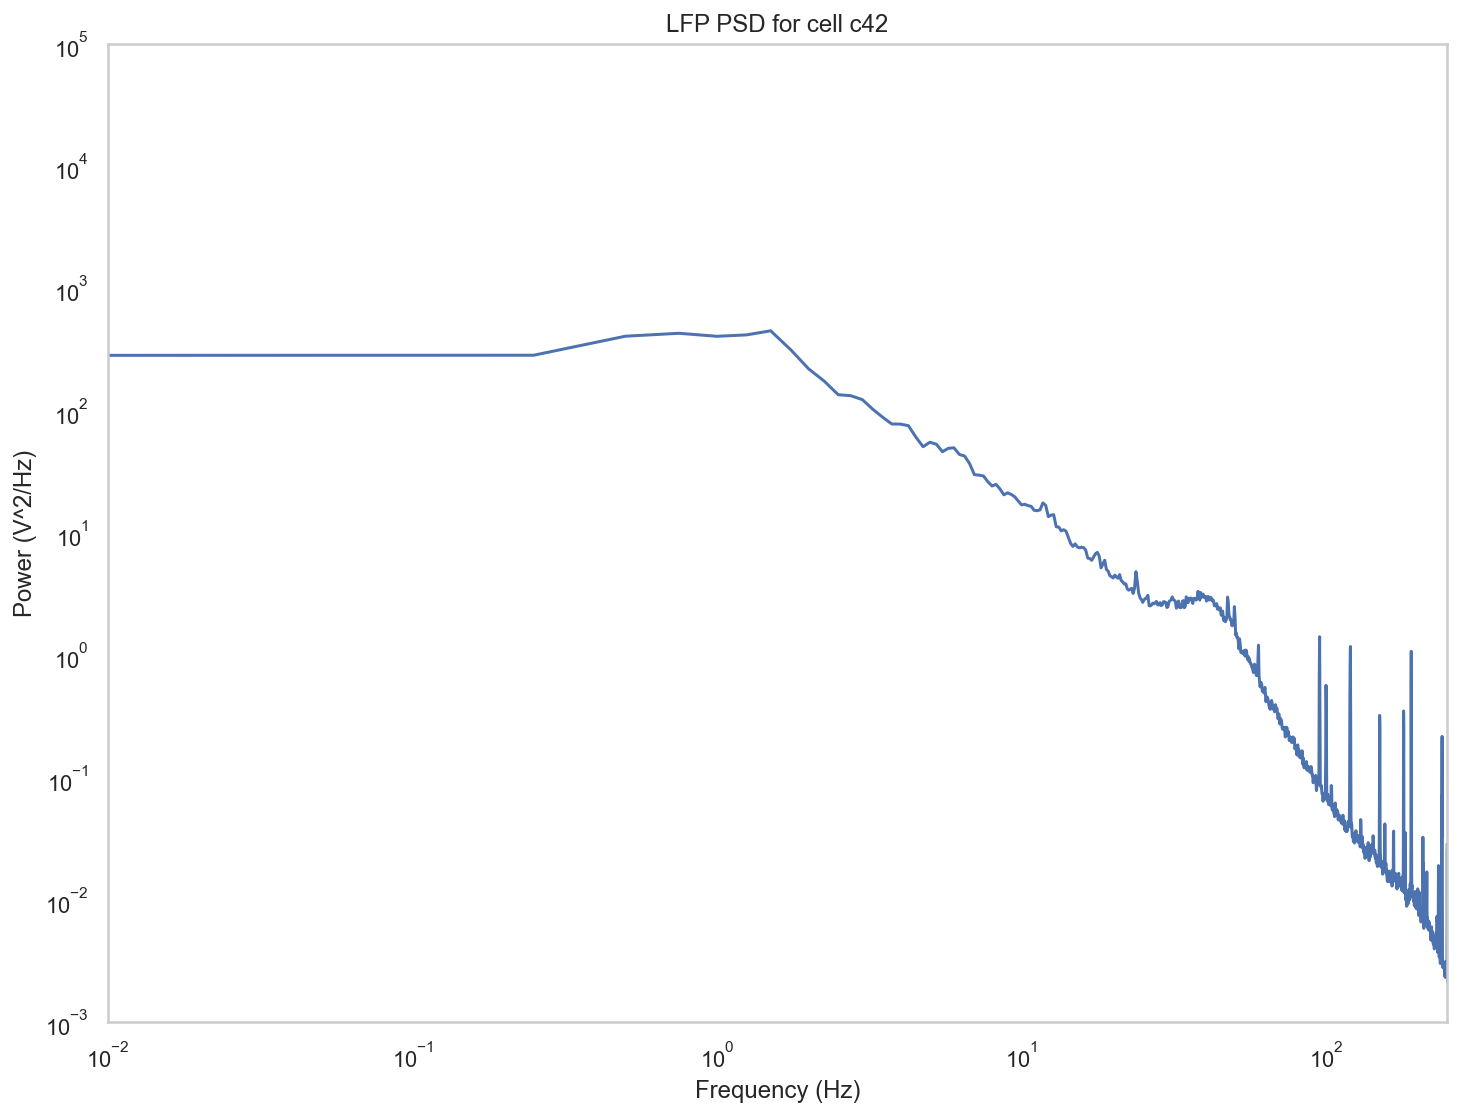

In [13]:
#plot PSD for cell 42
# plot power spectrum
fxx_c42, pxx_c42 = spectral.compute_spectrum(lfp_filt_c42, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx_c42, pxx_c42)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


#### 0. Use specpram to find gamma peaks

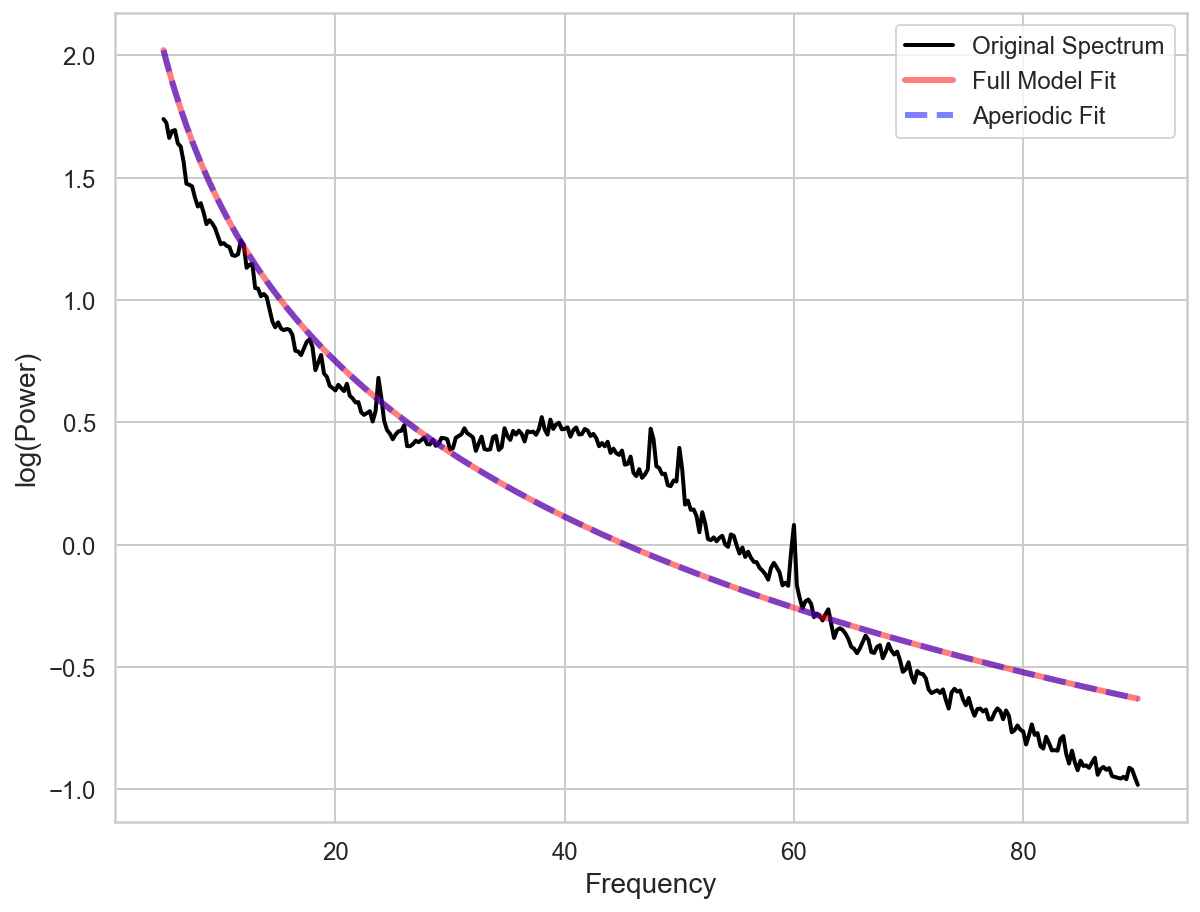

In [14]:
fm_c42 = FOOOF(max_n_peaks=0, verbose=False)
fm_c42.fit(fxx_c42, pxx_c42, freq_range=(5,90))
fm_c42.plot()

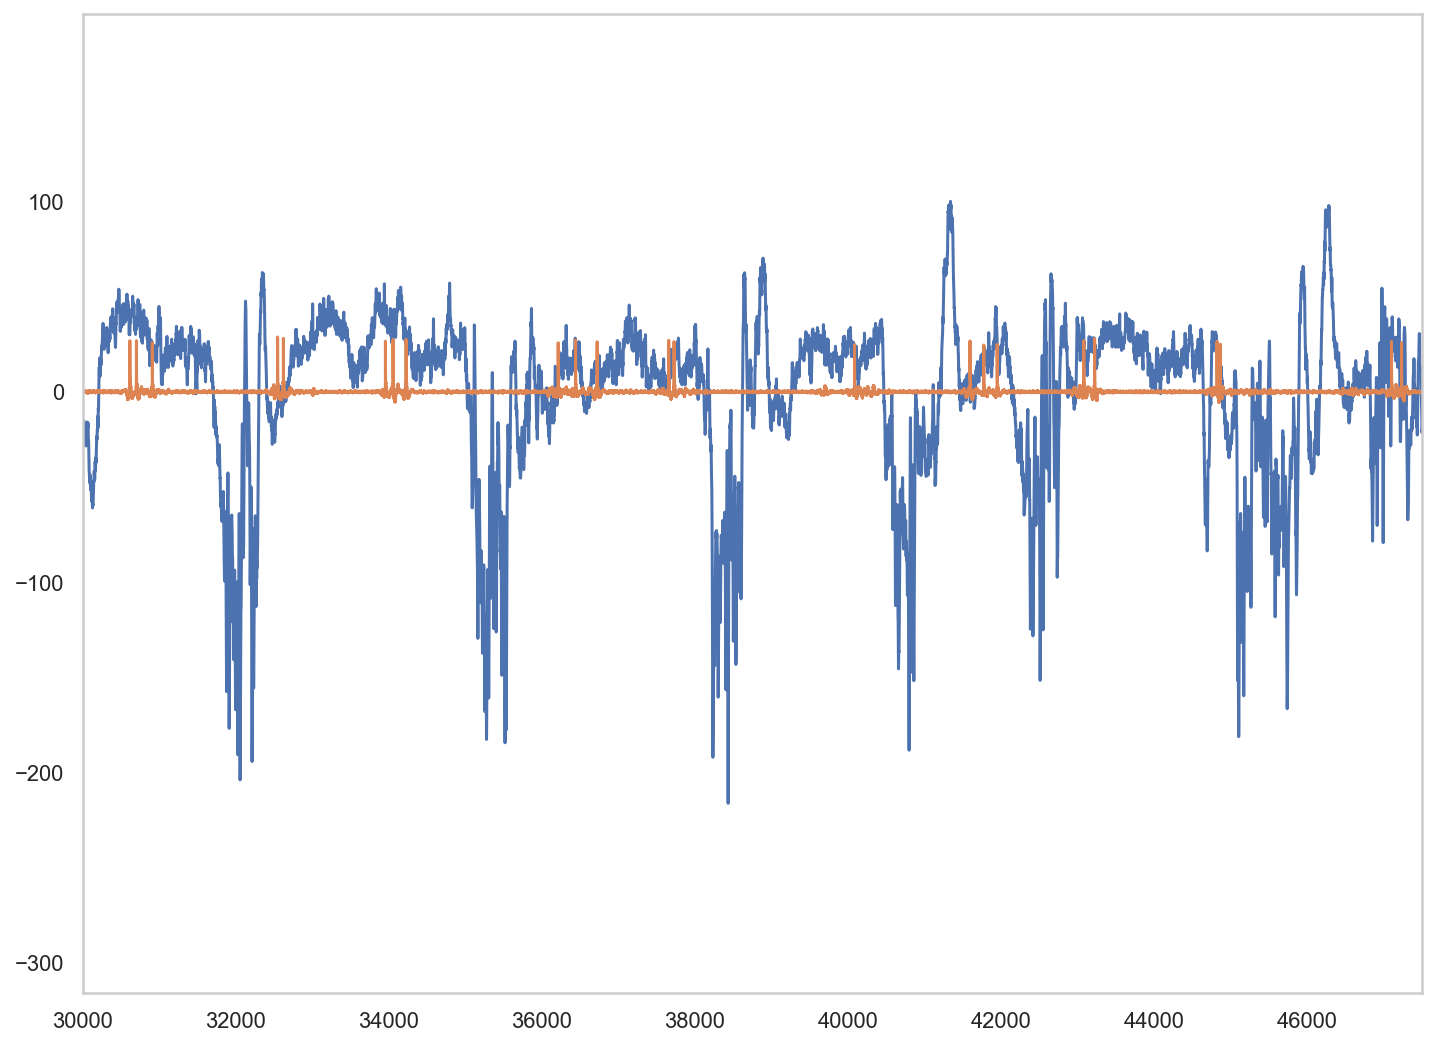

In [15]:
#plot raw LFP and patch data
plt.plot(lfp_times_c42, lfp_filt_c42)
plt.plot(patch_times_c42, patch_filt_c42)
plt.xlim(30000,47500)
plt.show()

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [16]:
gamma_peak = 40 #Hz 
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma_c42 = butter_bandpass(lfp_filt_c42, fs=lfp_fs, filt_freq=gamma_range, order=4)

#### 2. Get the analytic amplitude of the time series 

In [17]:
gamma_amp = amp_by_time(lfp_filt_gamma_c42, lfp_fs, gamma_range)

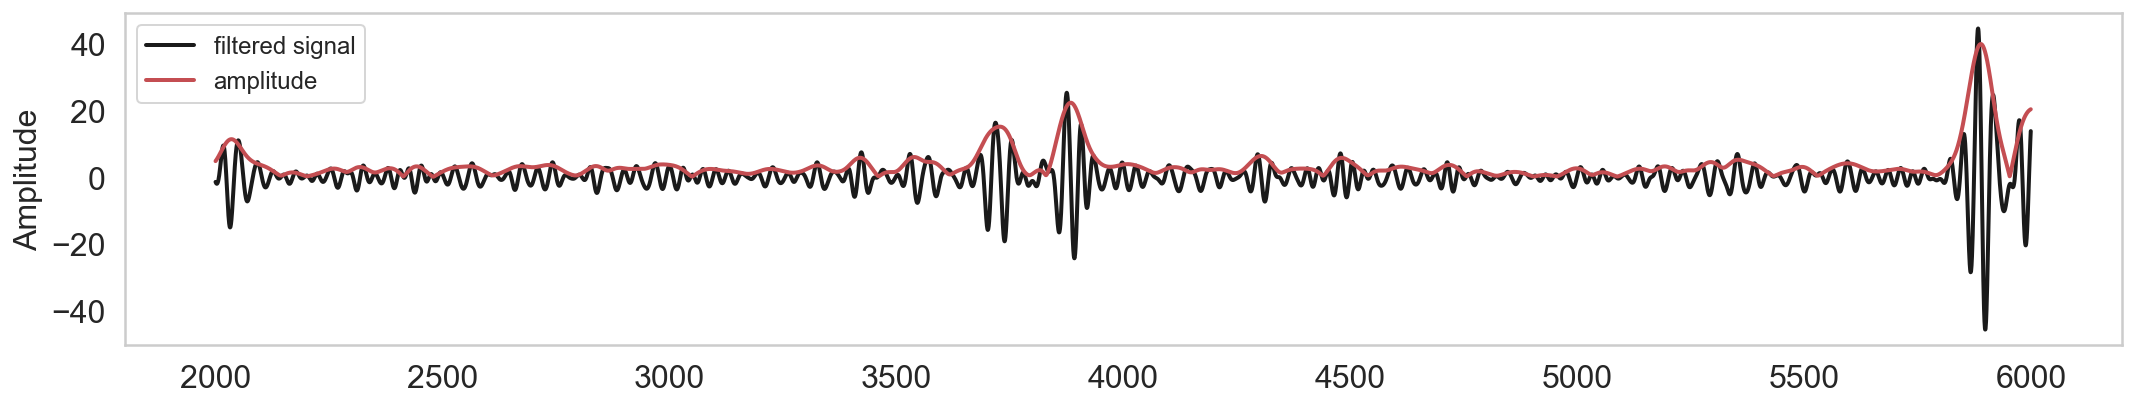

In [18]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

# Plot the filtered signal and oscillation amplitude
plot_instantaneous_measure(lfp_times_c42[tidx], [lfp_filt_gamma_c42[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion (3x median, 2std of the mean, whatever), and ends when it drops below another criterion (1.5x mean, 1std of mean)


#### Try 3 different moethods for gamma burst classifcation
#### Method 1: My own code to detect when analytic amplitude goes above some criteria - ignore for now (slower)
#### Method 2: neurodsp burst detection on gamma filtered data
#### Method 3: neurodsp burst detection on unfiltered data 

#### Method 2

In [157]:
xlim = (1000,20000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

In [158]:
###Try neurodsp burst detection method 
is_burst_m2 = detect_bursts_dual_threshold(lfp_filt_c42, lfp_fs, dual_thresh=(3, 1), f_range=(gamma_peak - 15, gamma_peak+15))


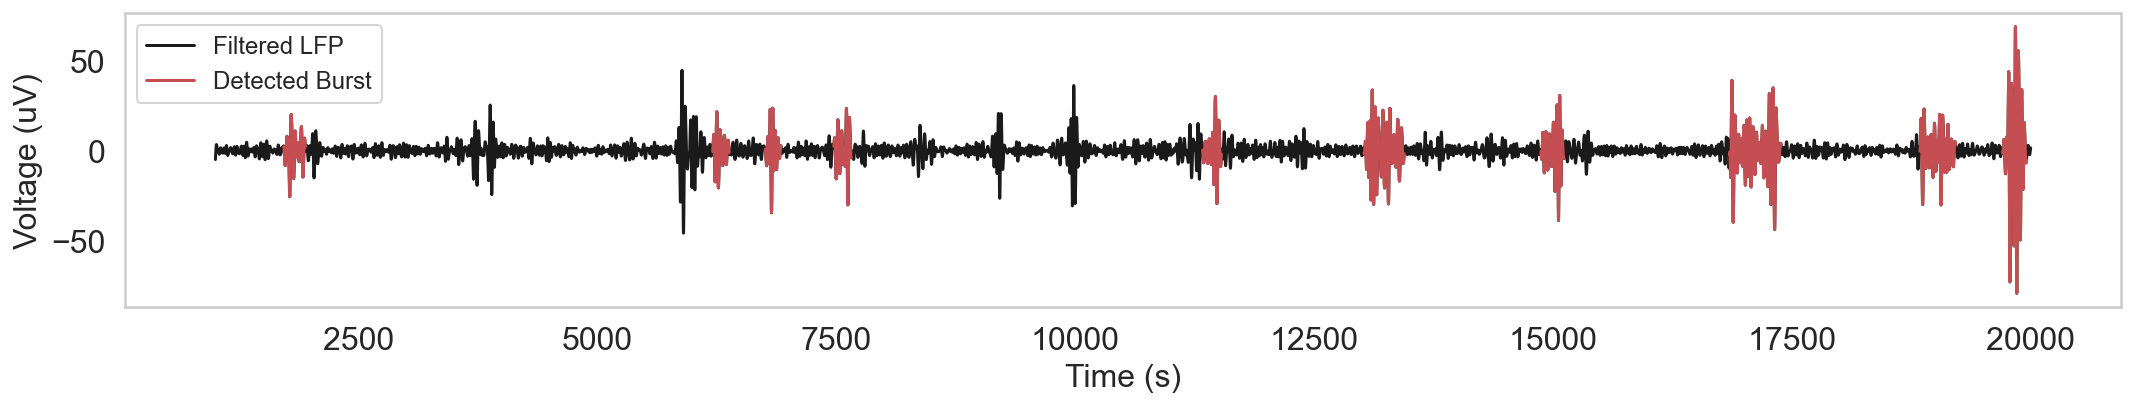

In [159]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_m2[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [160]:
gamma_bursts_ms_m2 = in_burst_to_burst_range_ms(is_burst_m2)


#### Method 3

In [161]:
###Try neurodsp burst detection method 
is_burst_m3 = detect_bursts_dual_threshold(lfp_filt_gamma_c42, lfp_fs, dual_thresh=(2, 1), f_range=(gamma_peak - 15, gamma_peak+15))


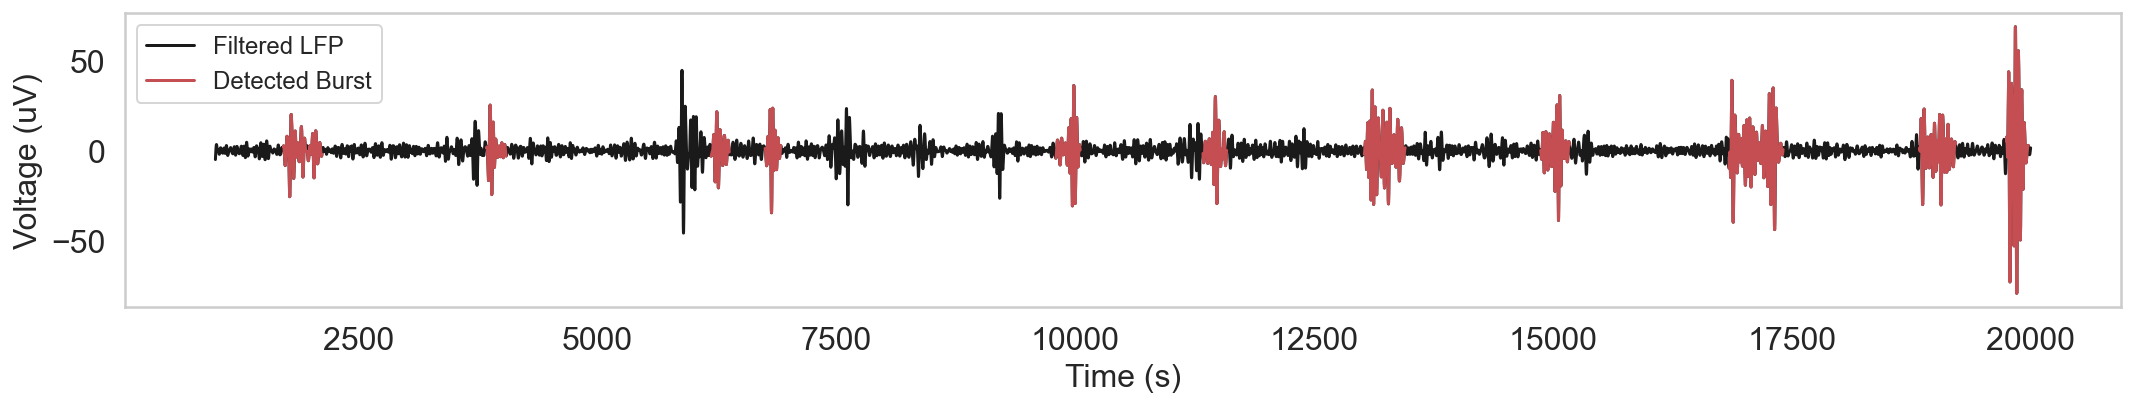

In [162]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_m3[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [163]:
gamma_bursts_ms_m3 = in_burst_to_burst_range_ms(is_burst_m3)

### Load and analyze extracellular spike data - IGNORE EXTRACELLULAR FOR NOW

In [26]:
"""
#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c42npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109"""


"\n#load npx data\nnpx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'\nnpx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c42npx_filt.npy'\nnpx_fs = 30000 # sampling rate\nnpx_one_ms = int(npx_fs / 1000)\nnpx_channels = 384\nnpx_patch_channel = 109"

In [27]:
"""# open and load the data
npx_filt = np.load(npx_path)"""

'# open and load the data\nnpx_filt = np.load(npx_path)'

In [28]:
"""npx_times_c42 = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

'npx_times_c42 = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec'

In [29]:
"""npx_times_c42 [-1]/60000"""

'npx_times_c42 [-1]/60000'

In [30]:
"""plt.plot(npx_filt[0:100000])"""

'plt.plot(npx_filt[0:100000])'

#### Detect extracellular spikes

In [31]:
"""sp_ex = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)

sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)"""

"sp_ex = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)\n\nsp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,\n       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))\n\nsp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)"

In [32]:
"""sp_ex.df_features"""

'sp_ex.df_features'

In [33]:
"""sp_ex.plot()"""

'sp_ex.plot()'

In [34]:
"""sp_ex.spike_inds"""

'sp_ex.spike_inds'

### Compute patch clamp spike features for cell 42

#### 4. compare the patched spike waveform for spikes that occur during an obvious gamma burst versus those are are obviously not in gamma. We’ll want to confirm this visually, looking at the time series as well.


In [35]:
#load patch clamp data for cell 42
patch_filt_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'
patch_fs = 50023.88170476
patch_one_ms = int(patch_fs / 1000)

In [36]:
patch_filt = np.load(patch_filt_dir)
patch_times = np.arange(0, np.shape(patch_filt)[0]) / patch_one_ms # in ms instead of sec


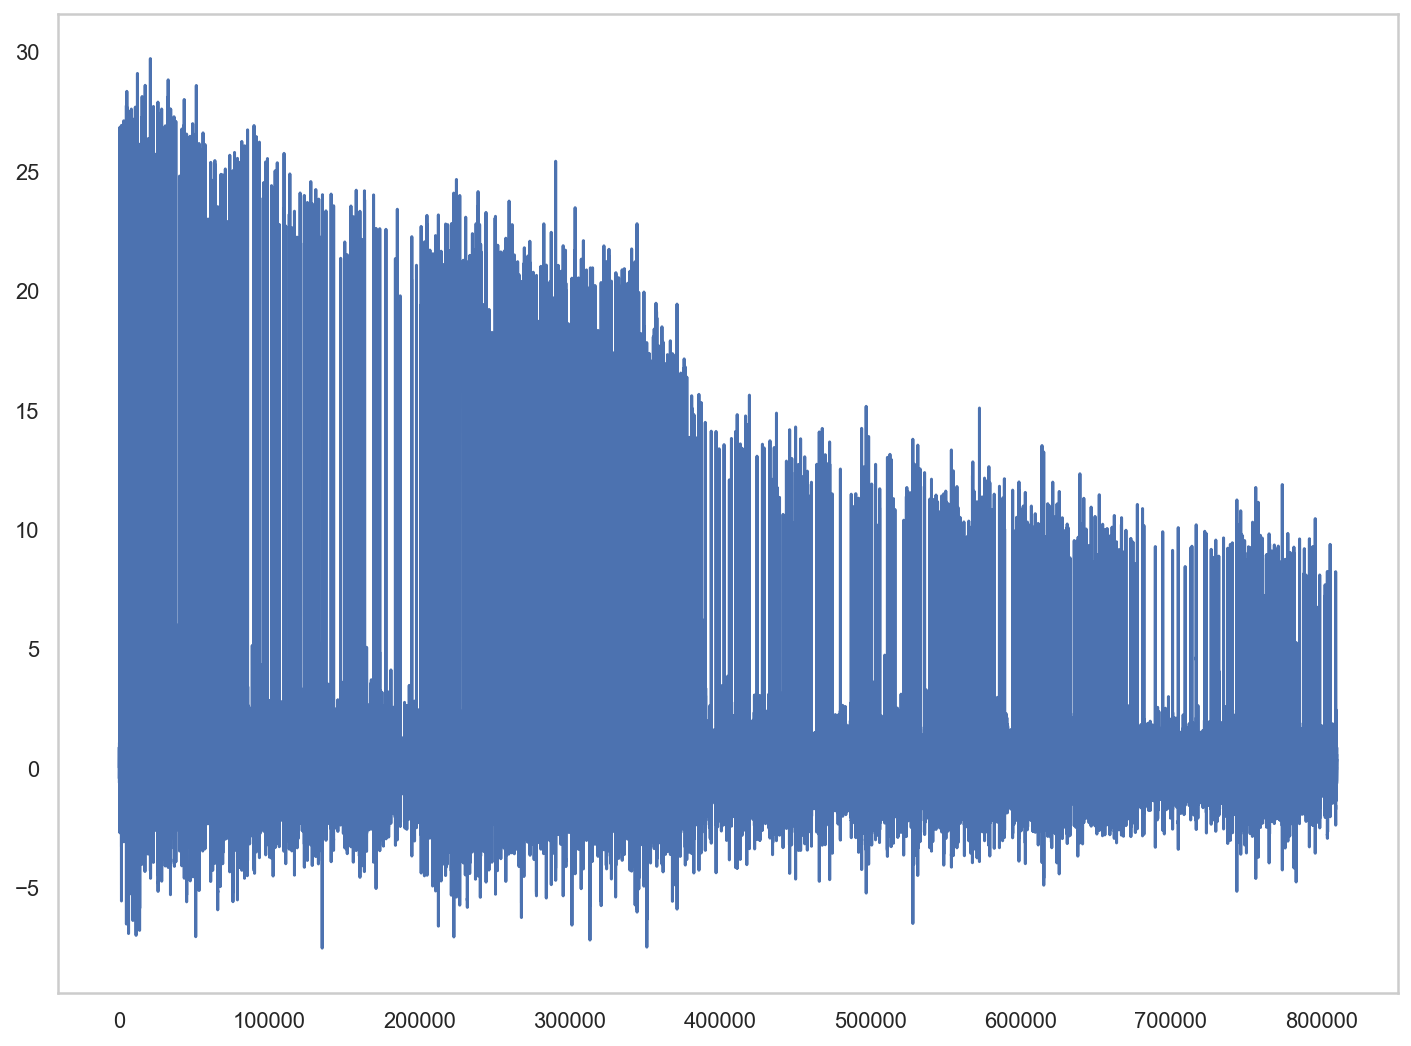

In [37]:
plt.plot(patch_times, patch_filt)

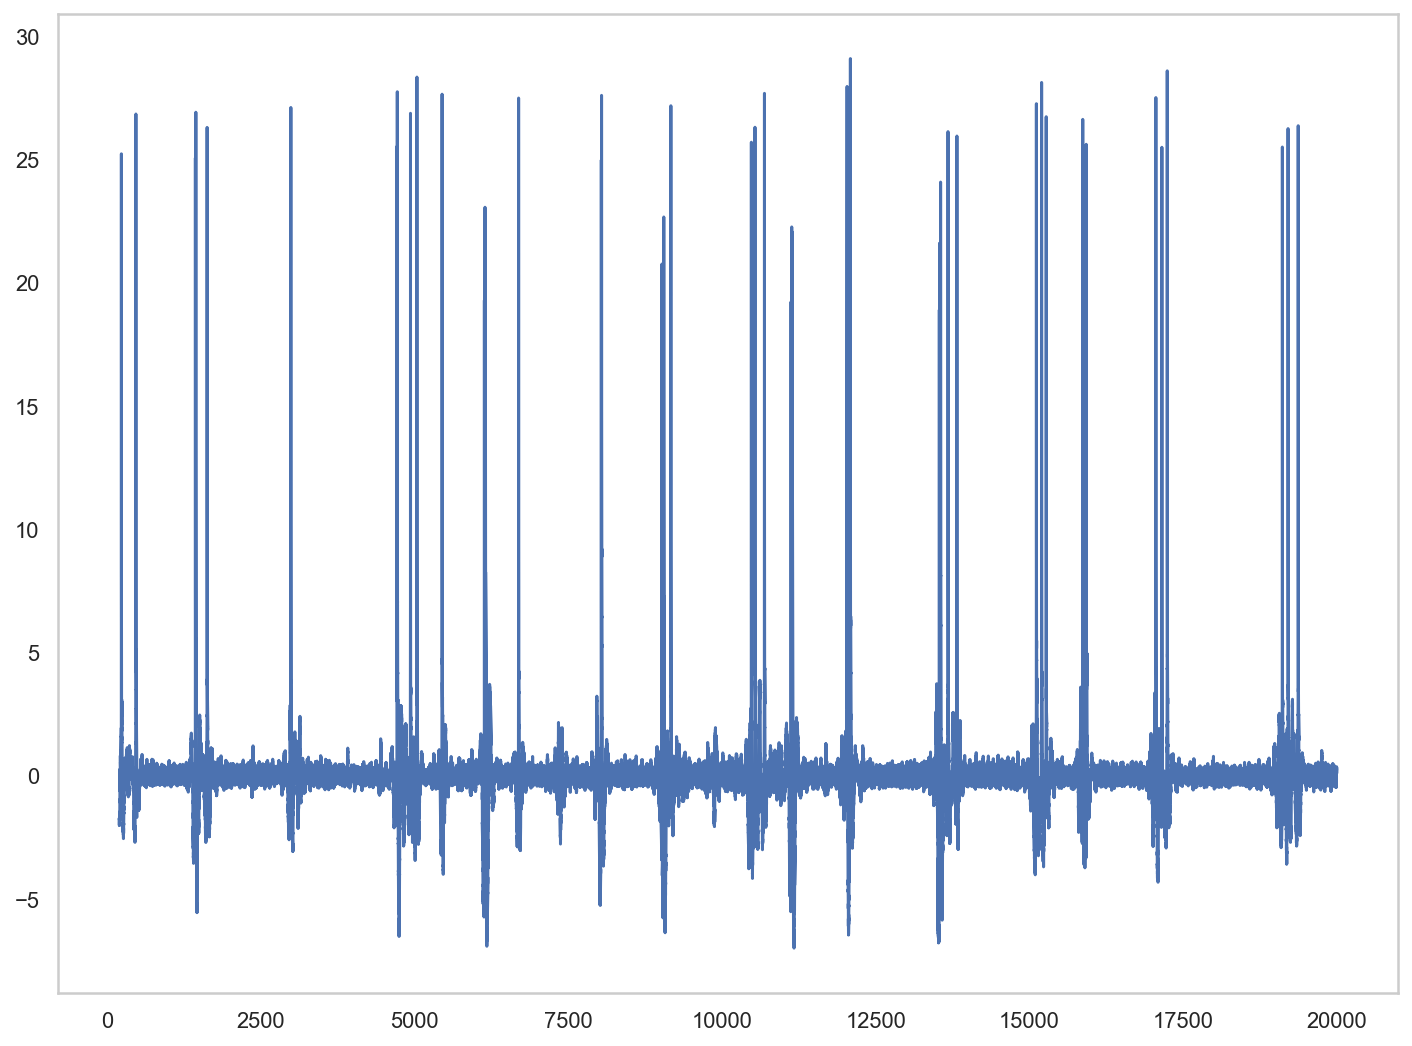

In [38]:
plt.plot(patch_times[10000:1000000], patch_filt[10000:1000000])

In [350]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

sp.alt(lfp_filt_c42, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3404 [00:00<?, ?it/s]

 ** On entry to DLASCLS parameter number  4 had an illegal value
 ** On entry to DLASCLS parameter number  4 had an illegal value


In [351]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,stim_mean,stim_std
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,0.000000,0.847685,0.996917,-50.463271,8.117908
1,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,236.247160,0.847685,0.996917,-50.463271,8.117908
2,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,966.738253,0.951638,0.987640,-62.891947,49.619044
3,1.009074,0.70,1.232428,24.959544,1.20,0.629029,1.388962,1.885119,7.736305,0.981525,0.997816,-89.229284,34.235396
4,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,0.779628,0.821644,0.999190,-64.840335,21.625966
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3399,-0.595647,1.04,3.605047,10.462961,4.12,0.197564,0.210425,3.639236,0.000000,0.878552,0.995857,40.091752,13.972849
3400,-0.595647,1.04,3.605047,10.462961,4.12,0.197564,0.210425,3.639236,0.000000,0.878552,0.995857,40.091752,13.972849
3401,-0.595647,1.04,3.605047,10.462961,4.12,0.197564,0.210425,3.639236,0.000000,0.878552,0.995857,40.091752,13.972849
3402,-0.595647,1.04,3.605047,10.462961,4.12,0.197564,0.210425,3.639236,0.000000,0.878552,0.995857,40.091752,13.972849


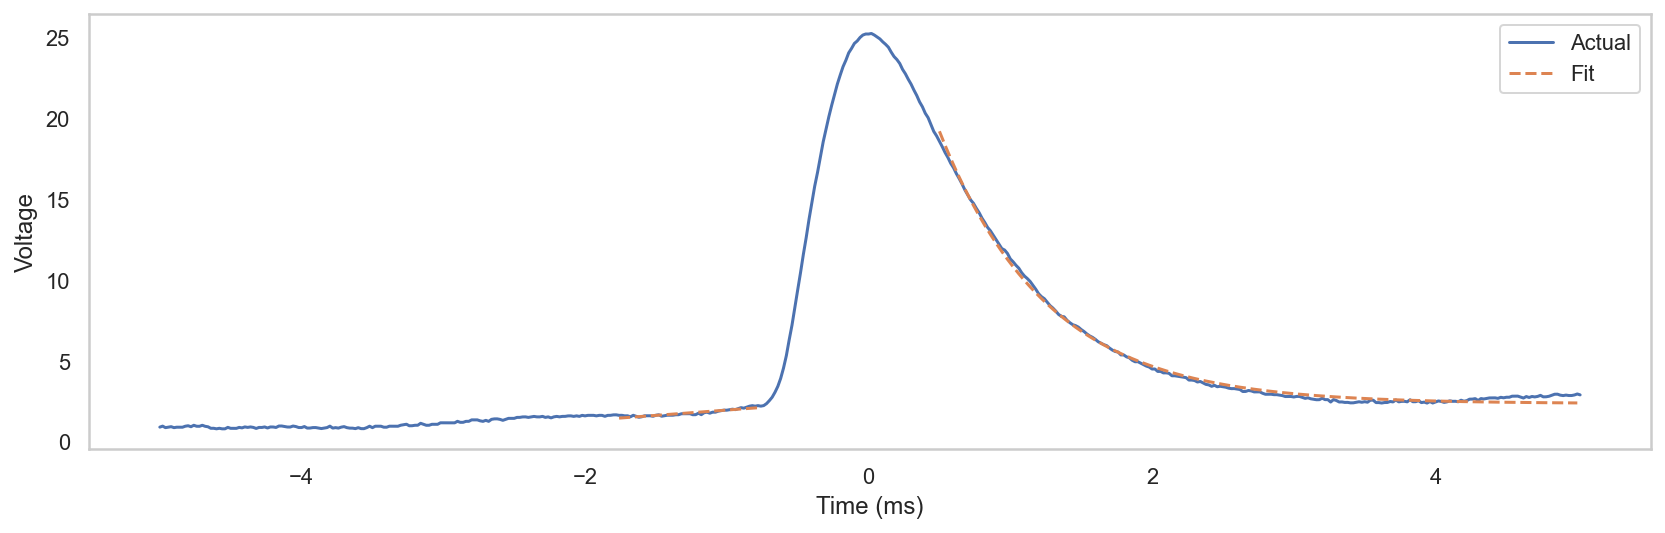

In [352]:
# First 100 fits
sp.plot(inds=np.arange(1), mode='full')

### Use detected spike indeces to determine if a spike occured during gamma peak or not

#### A) Get converted indices for gamma 'bursts'

In [353]:
gamma_bursts_ms_m2

[[188.0, 343.0],
 [1716.0, 1941.0],
 [6204.0, 6378.5],
 [6755.0, 6917.5],
 [7472.5, 7655.5],
 [11332.0, 11529.0],
 [13021.5, 13443.5],
 [14872.5, 15114.5],
 [16848.5, 17383.0],
 [18840.5, 19214.0],
 [19704.5, 19955.5],
 [21151.0, 21630.5],
 [23698.5, 23946.0],
 [23949.0, 24359.5],
 [25944.0, 26151.5],
 [28271.5, 28637.5],
 [29662.0, 29816.5],
 [31948.5, 32271.5],
 [35042.5, 35525.0],
 [38193.0, 38356.0],
 [38365.5, 38556.5],
 [40462.0, 40749.0],
 [42257.0, 42768.5],
 [45057.5, 45245.0],
 [45249.0, 45546.0],
 [45611.5, 45770.0],
 [46941.5, 47142.5],
 [47160.5, 47350.0],
 [49965.5, 50232.5],
 [50340.5, 50502.5],
 [51859.5, 52199.0],
 [53627.5, 53804.5],
 [53808.0, 54167.0],
 [55741.5, 55957.5],
 [56124.5, 56292.5],
 [60715.0, 60963.0],
 [60967.0, 61230.5],
 [61244.5, 61468.5],
 [63352.0, 63775.0],
 [63848.5, 64086.5],
 [66053.0, 66517.5],
 [69324.5, 69558.0],
 [70946.5, 71601.5],
 [73630.0, 73782.0],
 [73794.5, 74007.5],
 [74019.5, 74267.0],
 [75901.0, 76060.5],
 [76066.0, 76467.5],
 [77

In [354]:
gamma_bursts_ms_m3

[[186.5, 342.0],
 [435.0, 649.0],
 [1710.5, 1949.0],
 [1964.5, 2115.0],
 [3837.0, 4042.5],
 [6188.5, 6378.0],
 [6753.0, 6918.0],
 [9796.5, 10052.0],
 [11336.0, 11584.0],
 [13025.0, 13452.0],
 [14871.0, 15171.5],
 [16841.5, 17408.5],
 [18837.0, 19213.0],
 [19746.5, 19974.5],
 [21151.5, 21637.0],
 [23725.0, 23942.5],
 [23950.5, 24241.0],
 [25672.0, 25892.5],
 [25946.5, 26159.0],
 [26207.0, 26493.0],
 [28267.0, 28643.0],
 [29440.5, 29833.0],
 [31818.0, 32274.0],
 [35031.5, 35524.0],
 [35692.5, 35849.0],
 [35867.0, 36028.0],
 [38187.5, 38355.5],
 [38362.5, 38641.0],
 [40453.0, 40961.5],
 [42259.5, 42835.5],
 [45049.0, 45508.5],
 [45616.5, 45781.0],
 [46773.5, 47146.5],
 [47156.5, 47409.0],
 [49526.5, 49687.0],
 [49978.5, 50231.0],
 [50342.5, 50505.0],
 [51859.0, 52197.0],
 [53629.5, 54168.5],
 [55741.0, 55922.0],
 [55962.5, 56127.0],
 [56134.0, 56296.0],
 [58774.5, 59108.5],
 [60711.5, 61184.5],
 [61349.5, 61508.0],
 [63351.0, 63606.0],
 [63610.5, 63781.0],
 [63857.5, 64087.0],
 [65991.0, 

#### B) Get converted indices for lowest amp no gamma 'bursts'. Select areas not in bursts with the lowest analytic amplitude

In [355]:
ranges_not_burst_m2 = in_burst_to_burst_range_ms(np.invert(is_burst_m2), ms_convert=False)
ranges_not_burst_m3 = in_burst_to_burst_range_ms(np.invert(is_burst_m3), ms_convert=False)

#### Select ranges with lowest analytical amplitude 

In [356]:
not_burst_ms_m2 = get_lowest_analytical_amp(gamma_amp,ranges_not_burst_m2, lfp_one_ms)
not_burst_ms_m3 = get_lowest_analytical_amp(gamma_amp,ranges_not_burst_m3, lfp_one_ms)

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_46411/2299523990.py:10: RuntimeWarning: Mean of empty slice
  mean_am = np.nanmean(am_range)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_46411/2299523990.py:10: RuntimeWarning: Mean of empty slice
  mean_am = np.nanmean(am_range)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_46411/2299523990.py:10: RuntimeWarning: Mean of empty slice
  mean_am = np.nanmean(am_range)


#### Visualize regions in gamma burst and low amp no gamma 

##### Gamma detection method 2

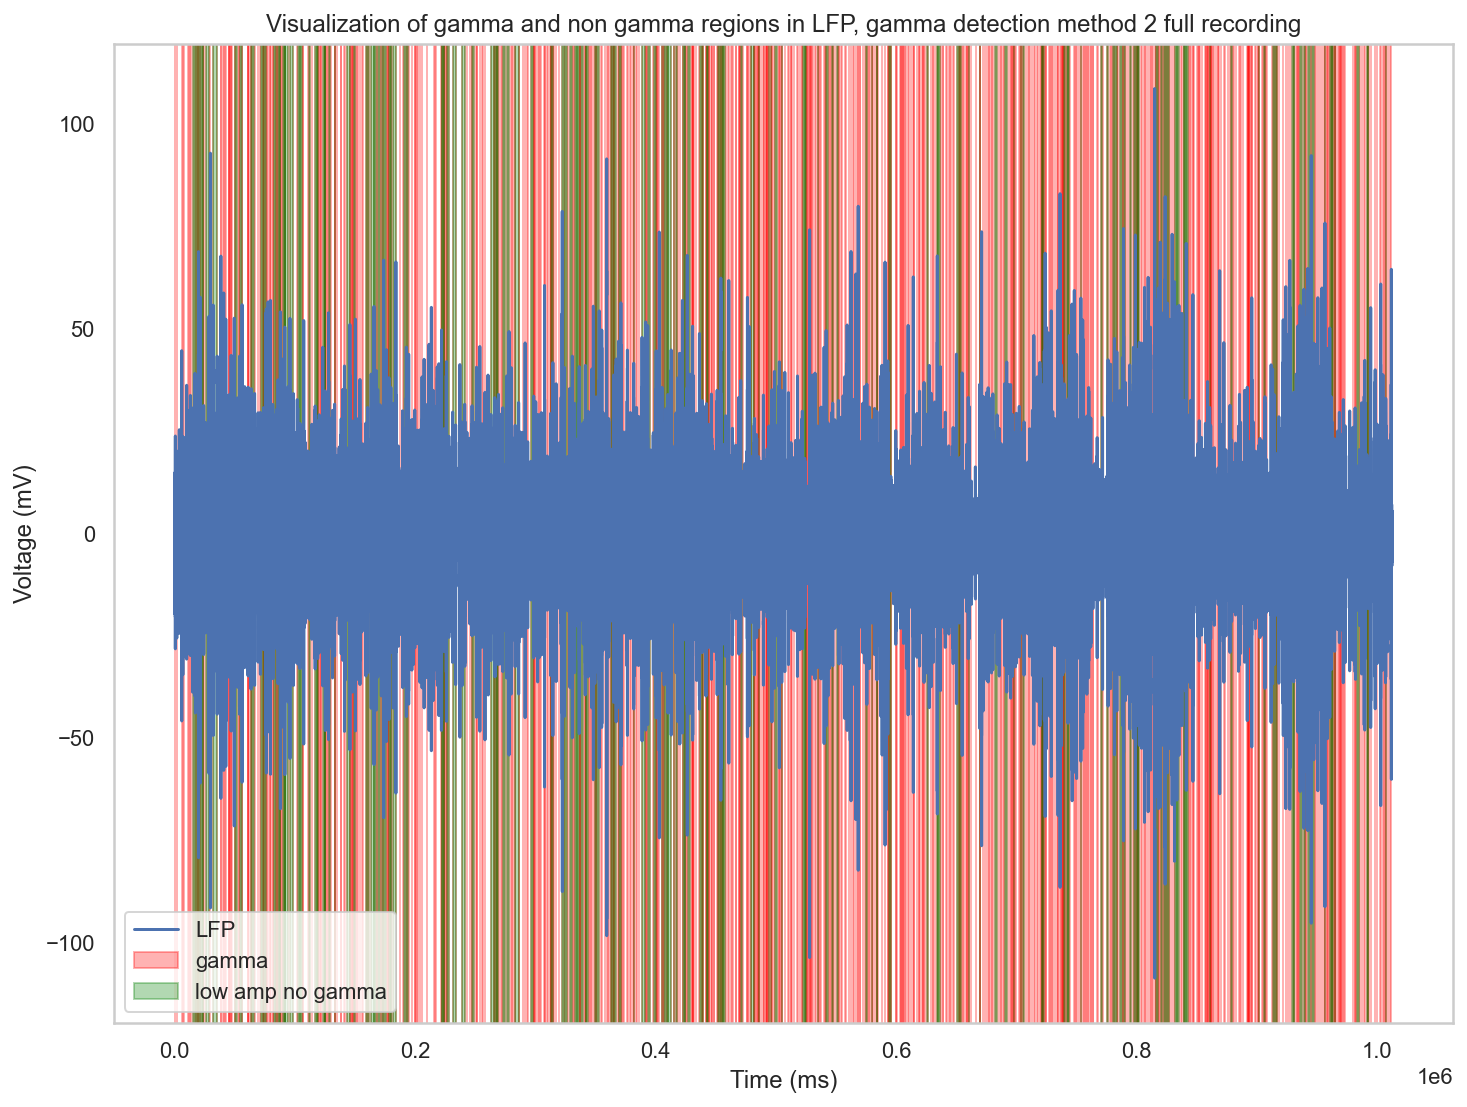

In [357]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=None)



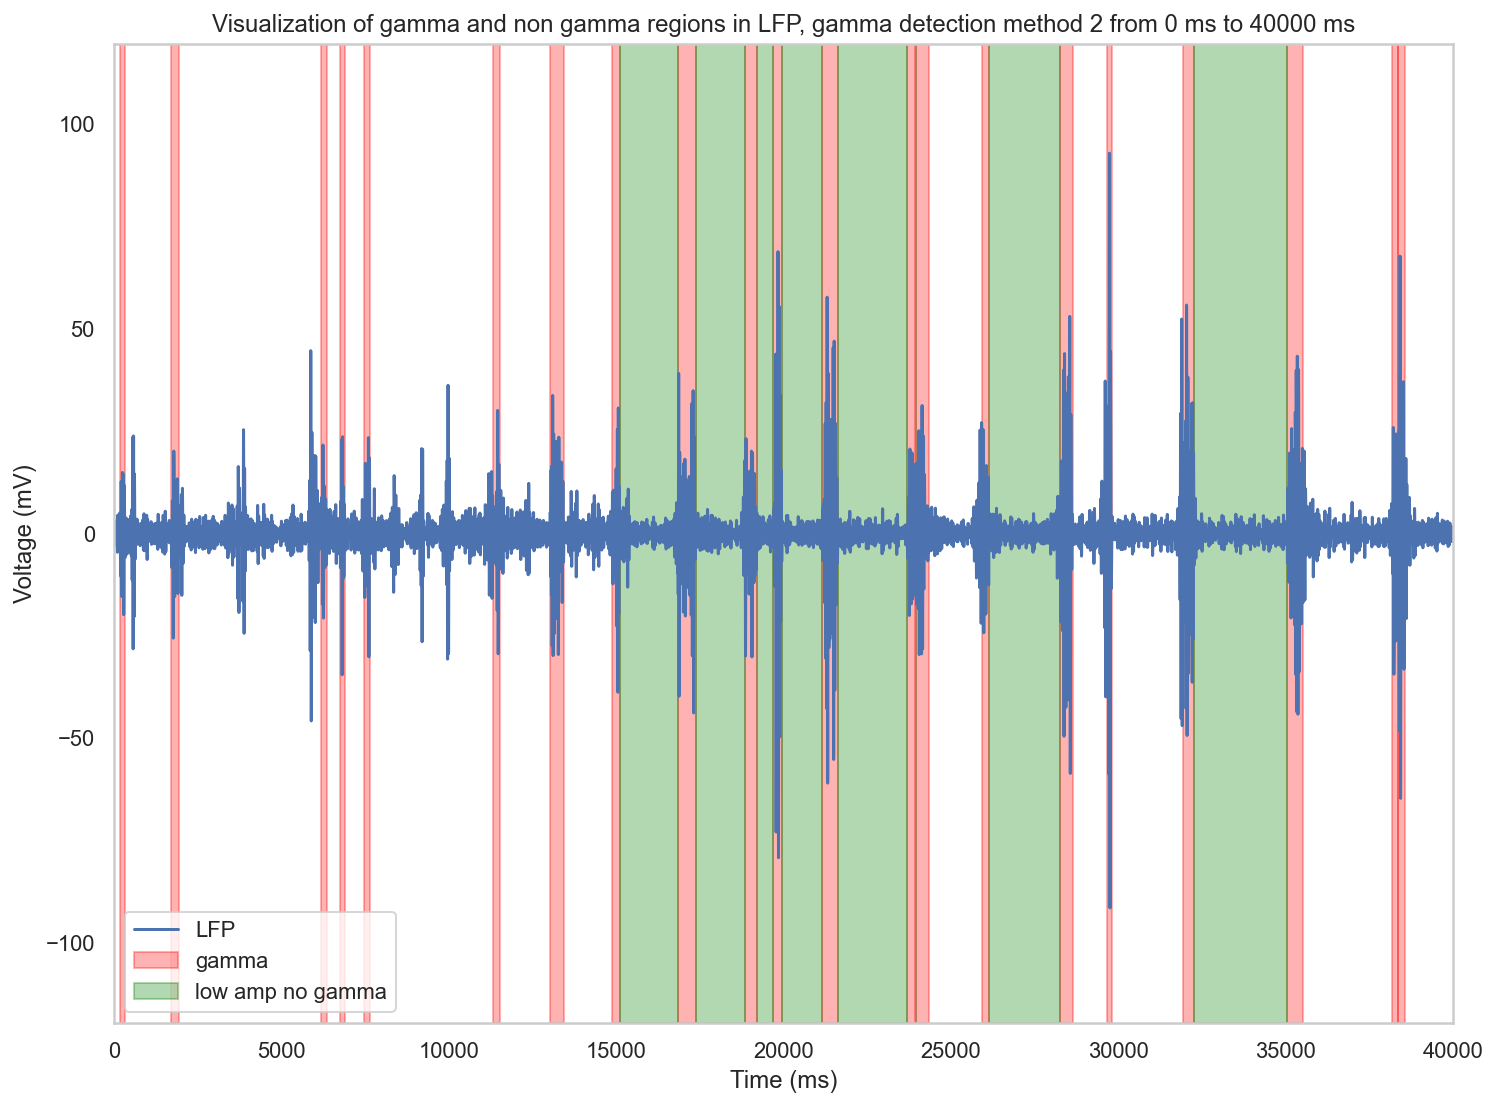

In [358]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=(0,40000))



###### Gamma detection method 3

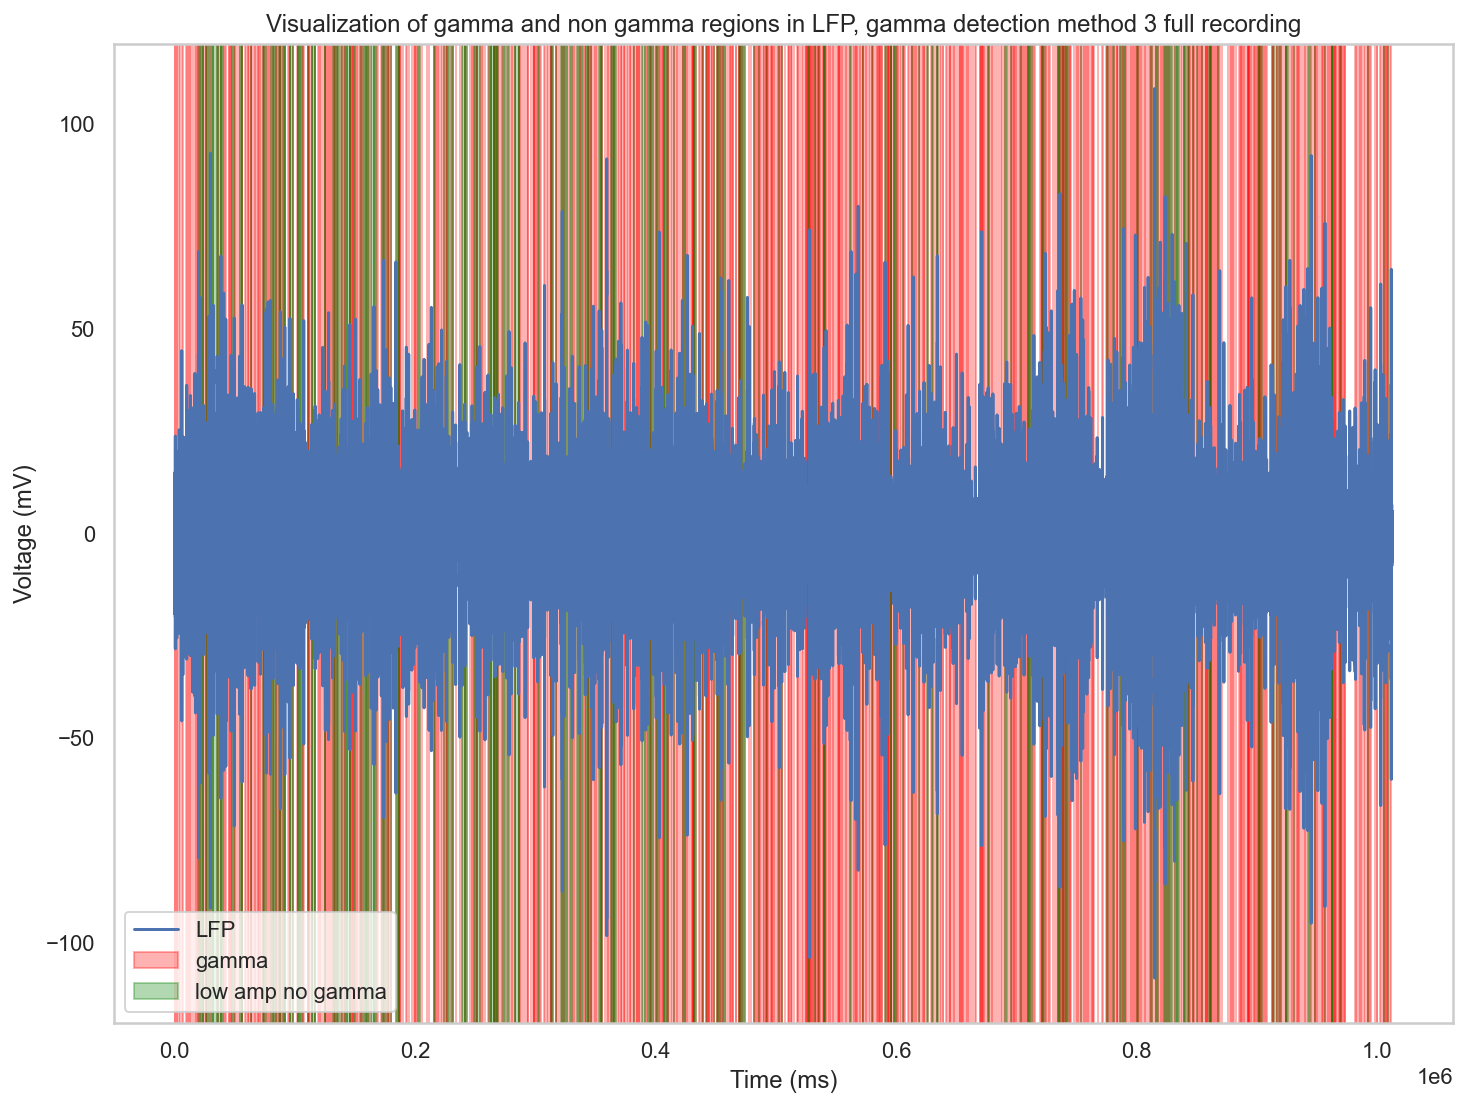

In [359]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=None)



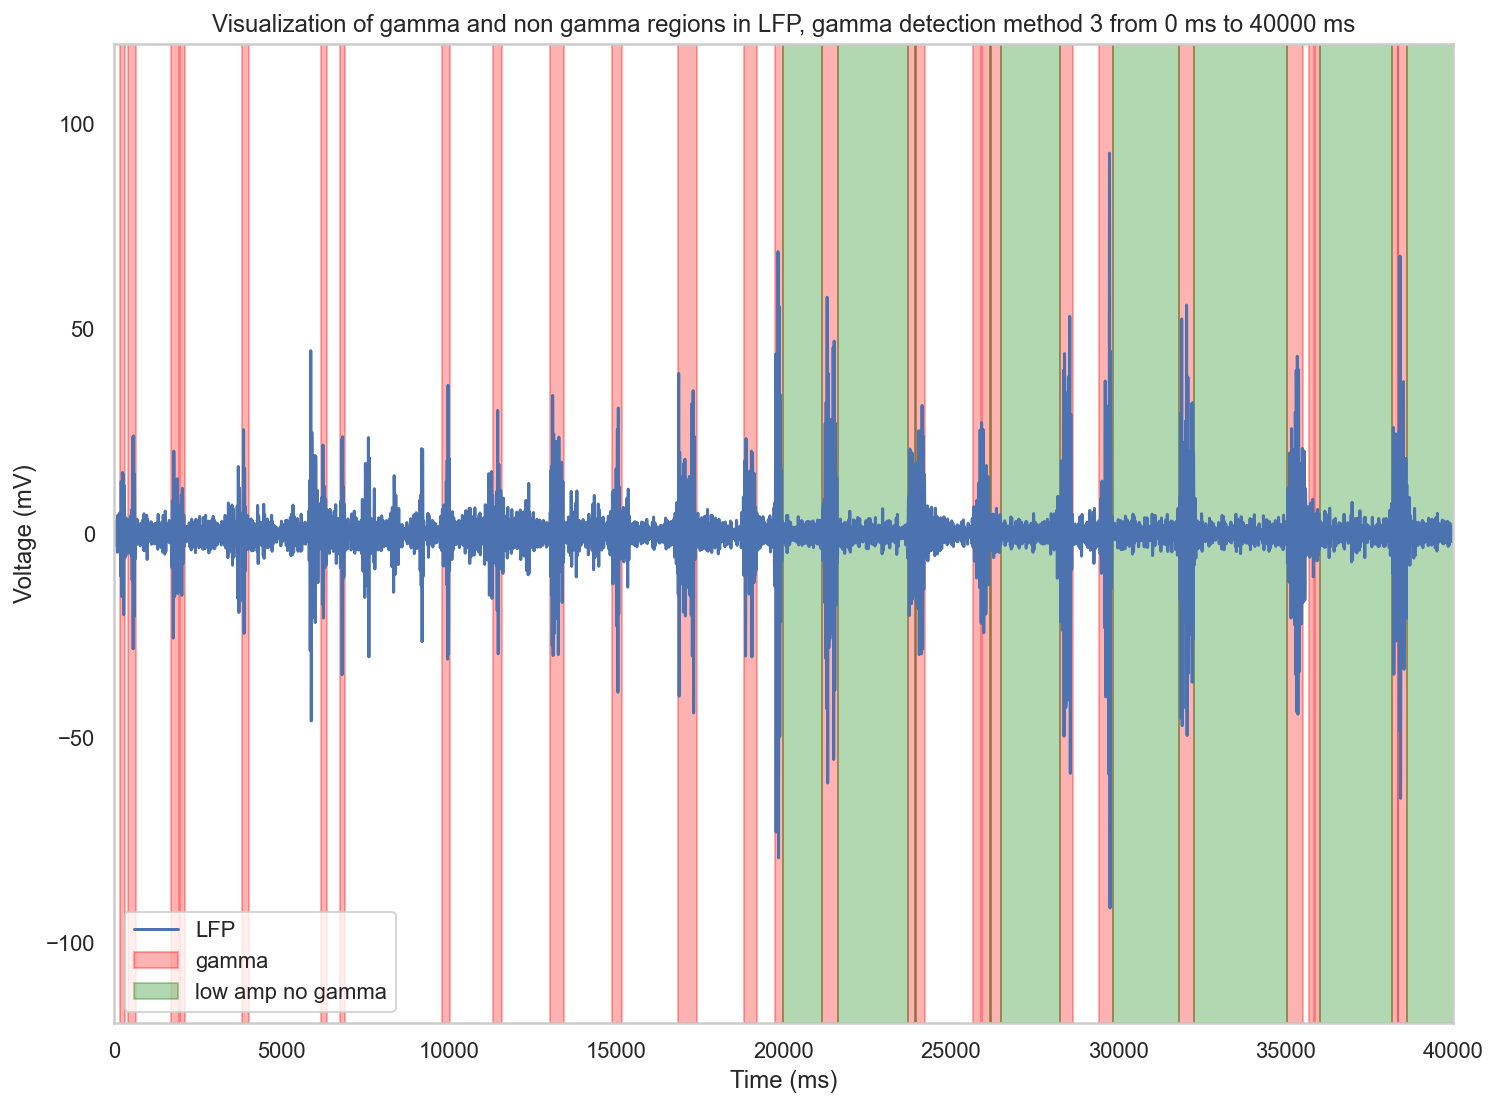

In [360]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(0,40000))



#### C) Determine what spikes are in which group 

In [361]:
spk_times_ms = patch_times_c42[sp.spike_inds]

In [365]:
spk_class_m2, spk_idx_m2, spk_idx_ms_m2 =  spk_lfp_class(spk_times_ms, not_burst_ms_m2, gamma_bursts_ms_m2)

spk_class_m3, spk_idx_m3, spk_idx_ms_m3 =  spk_lfp_class(spk_times_ms, not_burst_ms_m3, gamma_bursts_ms_m3)


In [366]:
occurrence_m2 = {item: spk_class_m2.count(item) for item in spk_class_m2}
occurrence_m3 = {item: spk_class_m3.count(item) for item in spk_class_m3}

In [367]:
occurrence_m2

{'gamma': 688, 'no_gamma': 549}

In [368]:
occurrence_m3

{'gamma': 820, 'no_gamma': 345}

#### E) Compare features of gamma and no gamma spikes

In [369]:
#Get features for gamma spikes
idx_gamma_m2 = np.where(np.array(spk_class_m2) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma_m2 = np.asarray(spk_idx_m2)[np.asarray(idx_gamma_m2)]
spk_gamma_features_m2 = sp.df_features.iloc[spk_idx_gamma_m2]

In [370]:
#Get features for gamma spikes
idx_gamma_m3 = np.where(np.array(spk_class_m3) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma_m3 = np.asarray(spk_idx_m3)[np.asarray(idx_gamma_m3)]
spk_gamma_features_m3 = sp.df_features.iloc[spk_idx_gamma_m3]

In [371]:
#Get features for no gamma spikes
idx_no_gamma_m2 = np.where(np.array(spk_class_m2) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma_m2 = np.asarray(spk_idx_m2)[np.asarray(idx_no_gamma_m2)]
spk_no_gamma_features_m2 = sp.df_features.iloc[spk_idx_no_gamma_m2]

In [372]:
#Get features for no gamma spikes
idx_no_gamma_m3 = np.where(np.array(spk_class_m3) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma_m3 = np.asarray(spk_idx_m3)[np.asarray(idx_no_gamma_m3)]
spk_no_gamma_features_m3 = sp.df_features.iloc[spk_idx_no_gamma_m3]

#### Visualize categorized spikes and LFP groups


In [373]:
gamma_spks_m2 = np.asarray(spk_idx_ms_m2)[np.asarray(idx_gamma_m2)]
no_gamma_spks_m2 = np.asarray(spk_idx_ms_m2)[np.asarray(idx_no_gamma_m2)]

gamma_spks_m3 = np.asarray(spk_idx_ms_m3)[np.asarray(idx_gamma_m3)]
no_gamma_spks_m3 = np.asarray(spk_idx_ms_m3)[np.asarray(idx_no_gamma_m3)]

###### Method 2

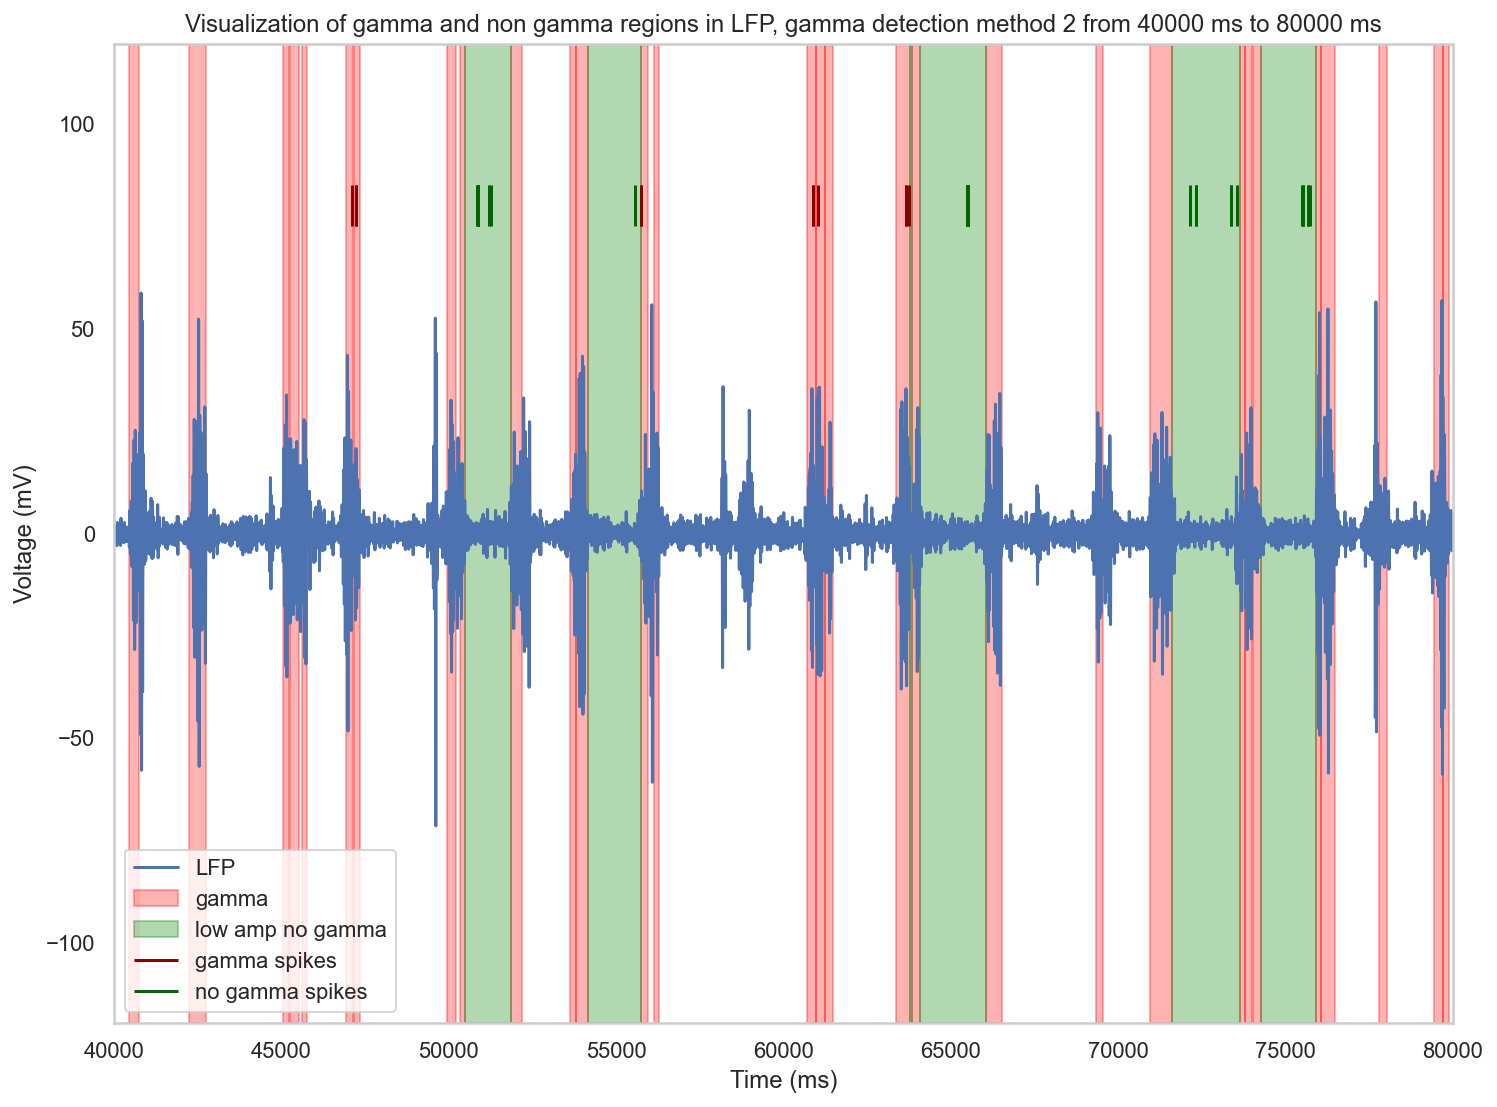

In [375]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=(40000,80000), plot_spk=True, spk_gamma= gamma_spks_m2, spk_nogamma=no_gamma_spks_m2)


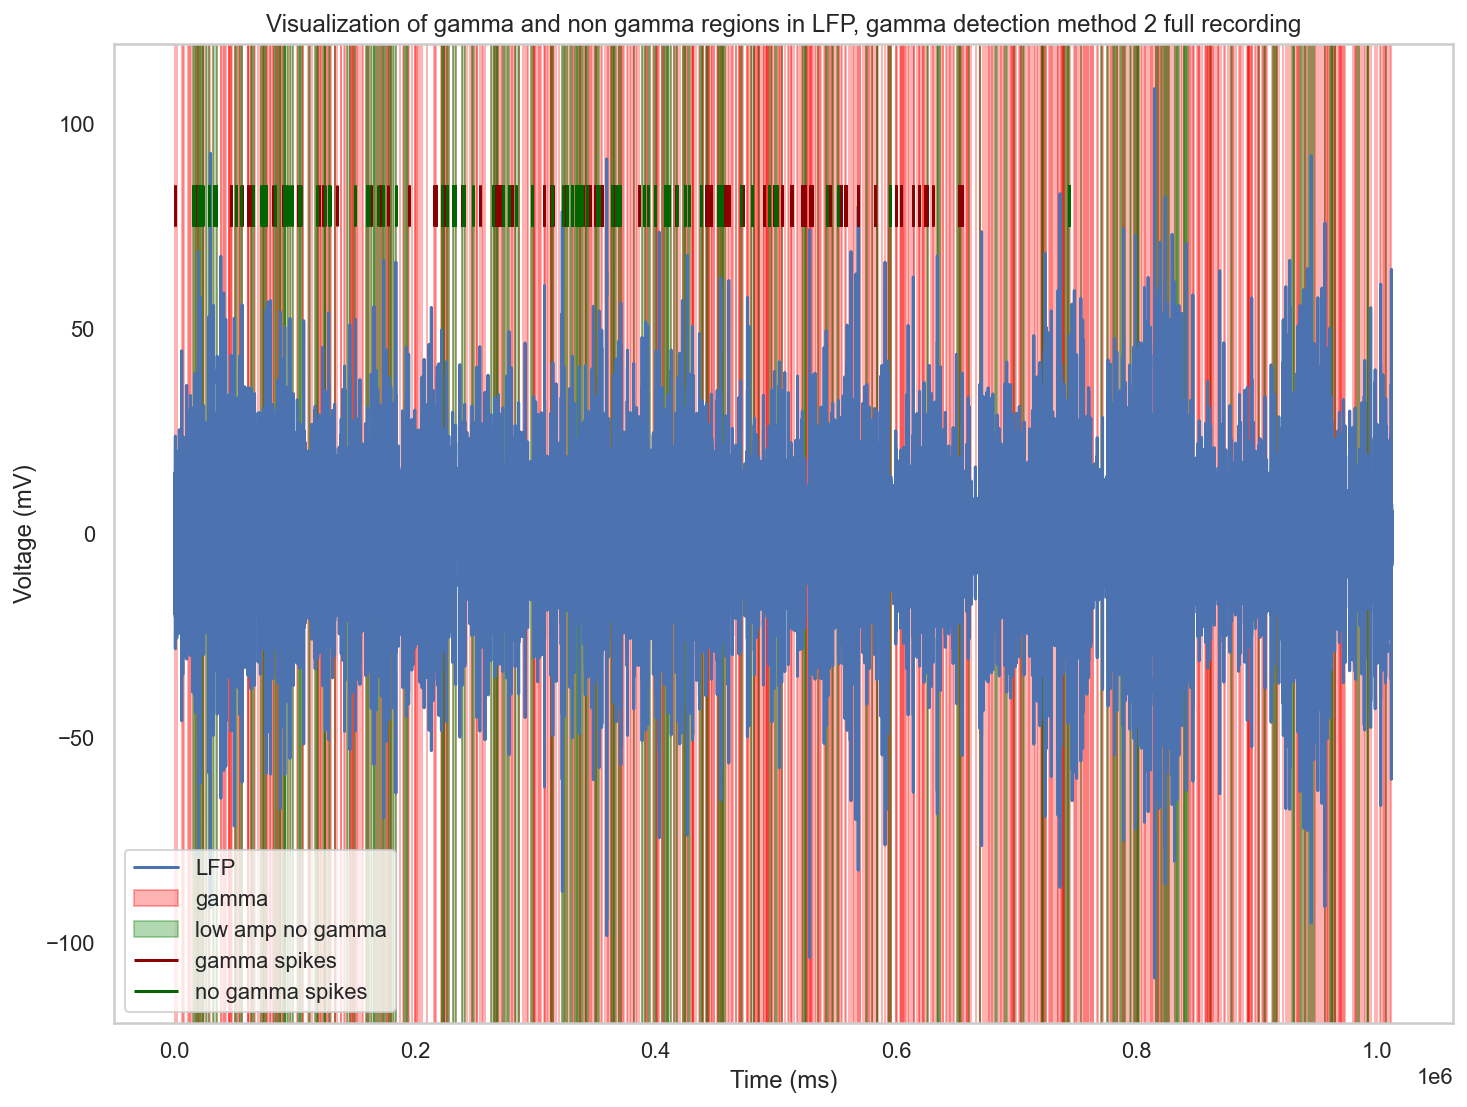

In [376]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', plot_spk=True, spk_gamma= gamma_spks_m2, spk_nogamma=no_gamma_spks_m2)


##### Method 3

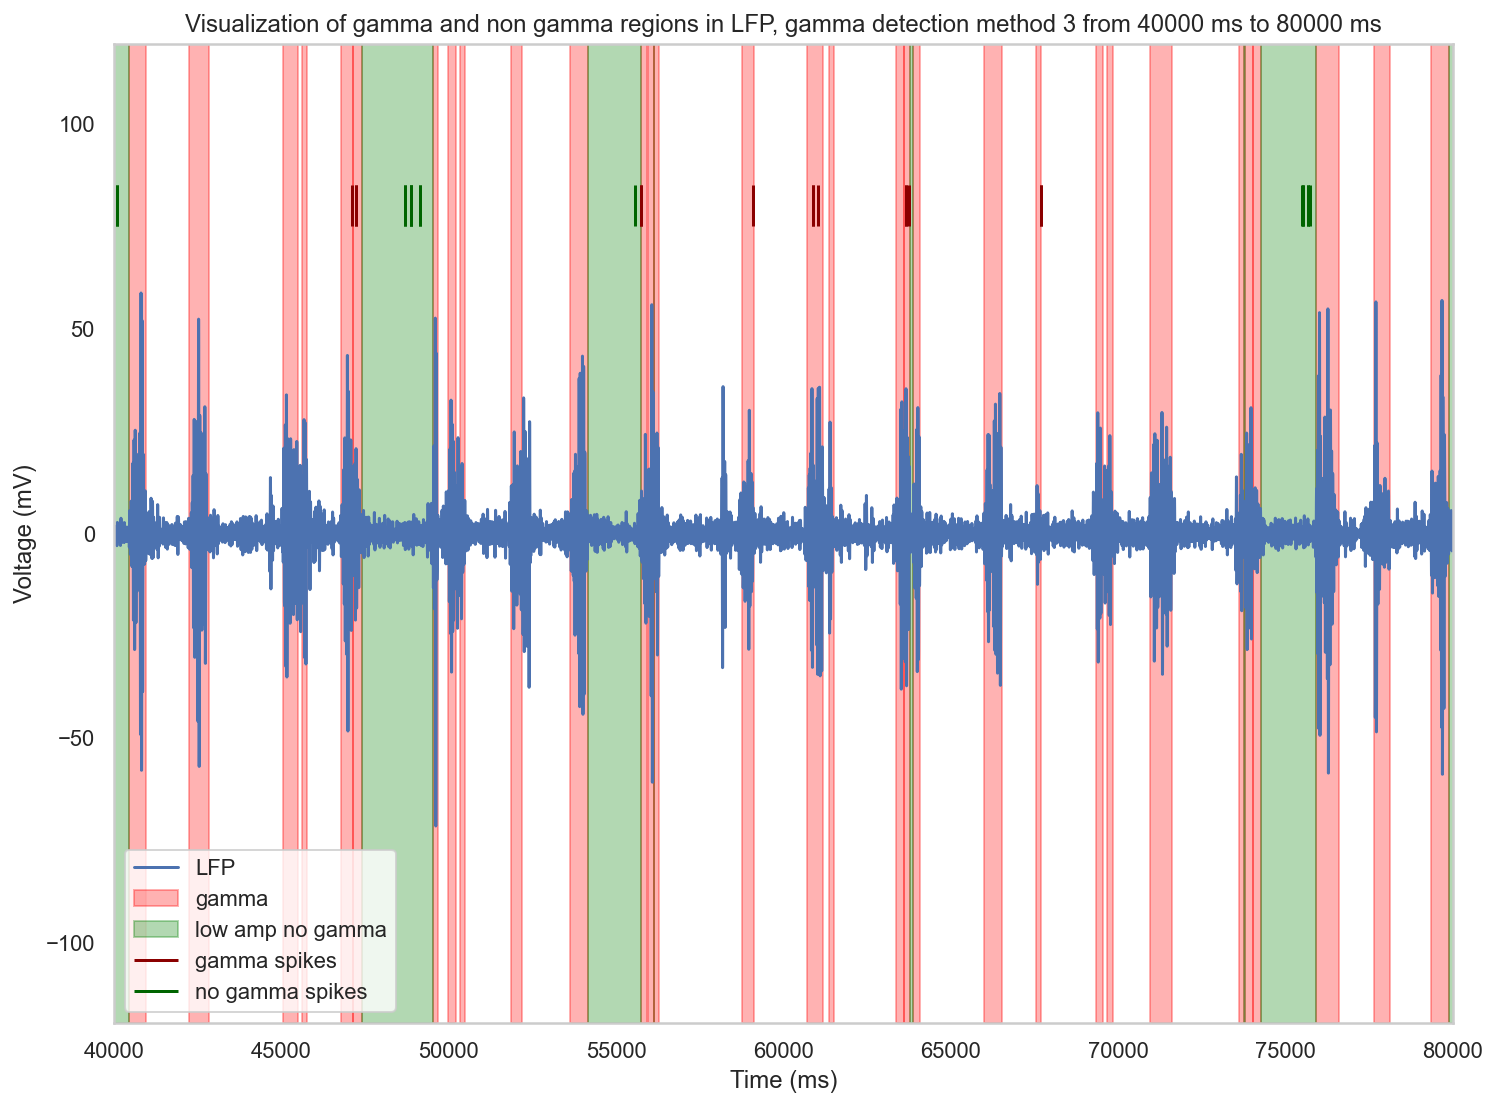

In [377]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(40000,80000), plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)


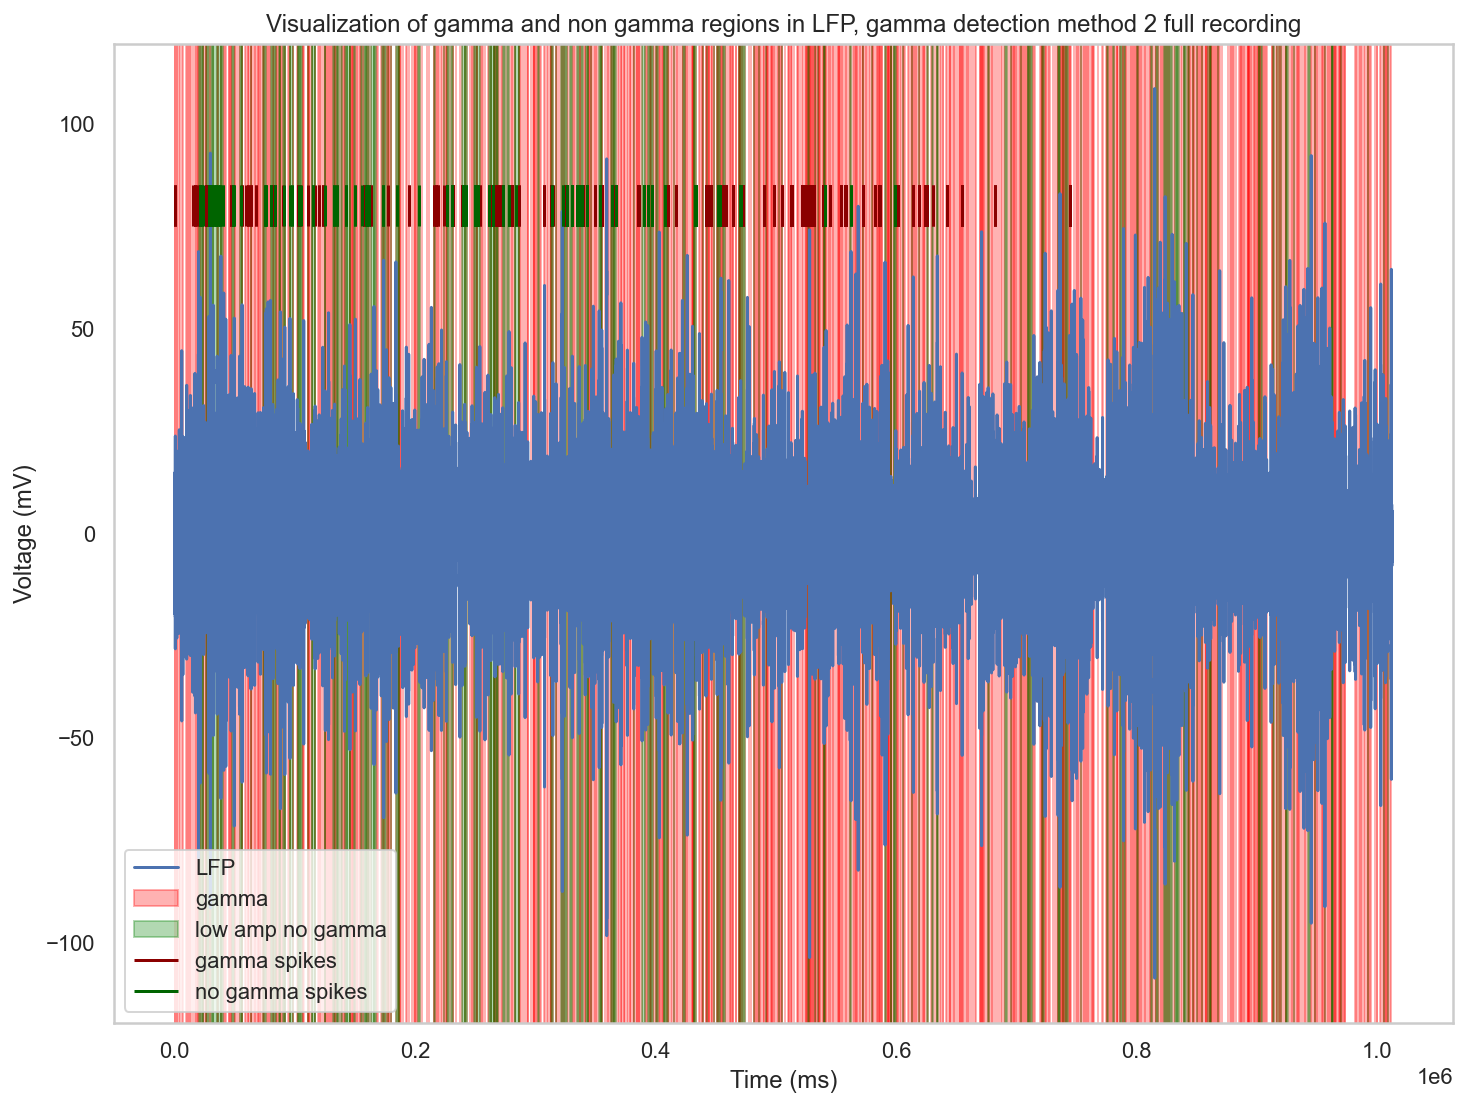

In [378]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)


### (For now) - from here onwards I am just using the method 2 results

##### Gamma features

In [380]:
spk_gamma_features_m2

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,stim_mean,stim_std
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,0.000000,0.847685,0.996917,-50.463271,8.117908
1,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,236.247160,0.847685,0.996917,-50.463271,8.117908
216,0.996990,0.74,3.868878,27.462563,1.22,0.658564,1.258951,4.281266,97.673348,0.968650,0.999485,-109.877508,37.792683
217,0.950415,0.70,1.531837,25.351521,1.20,0.715407,1.276490,2.345120,87.038427,0.915682,0.999264,-70.012179,11.317864
218,1.126602,0.74,4.988691,28.515338,1.18,0.520198,1.343561,4.523581,0.000000,0.954472,0.998693,-106.183009,24.348341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3241,0.335235,0.66,2.269477,10.169744,2.02,0.153336,0.411945,1.909777,0.000000,0.477750,0.993246,-5.702987,17.683163
3242,0.335235,0.66,2.269477,10.169744,2.02,0.153336,0.411945,1.909777,0.000000,0.477750,0.993246,-5.702987,17.683163
3243,0.335235,0.66,2.269477,10.169744,2.02,0.153336,0.411945,1.909777,0.000000,0.477750,0.993246,-5.702987,17.683163
3244,0.335235,0.66,2.269477,10.169744,2.02,0.153336,0.411945,1.909777,0.000000,0.477750,0.993246,-5.702987,17.683163


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/internals/blocks.py:402: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


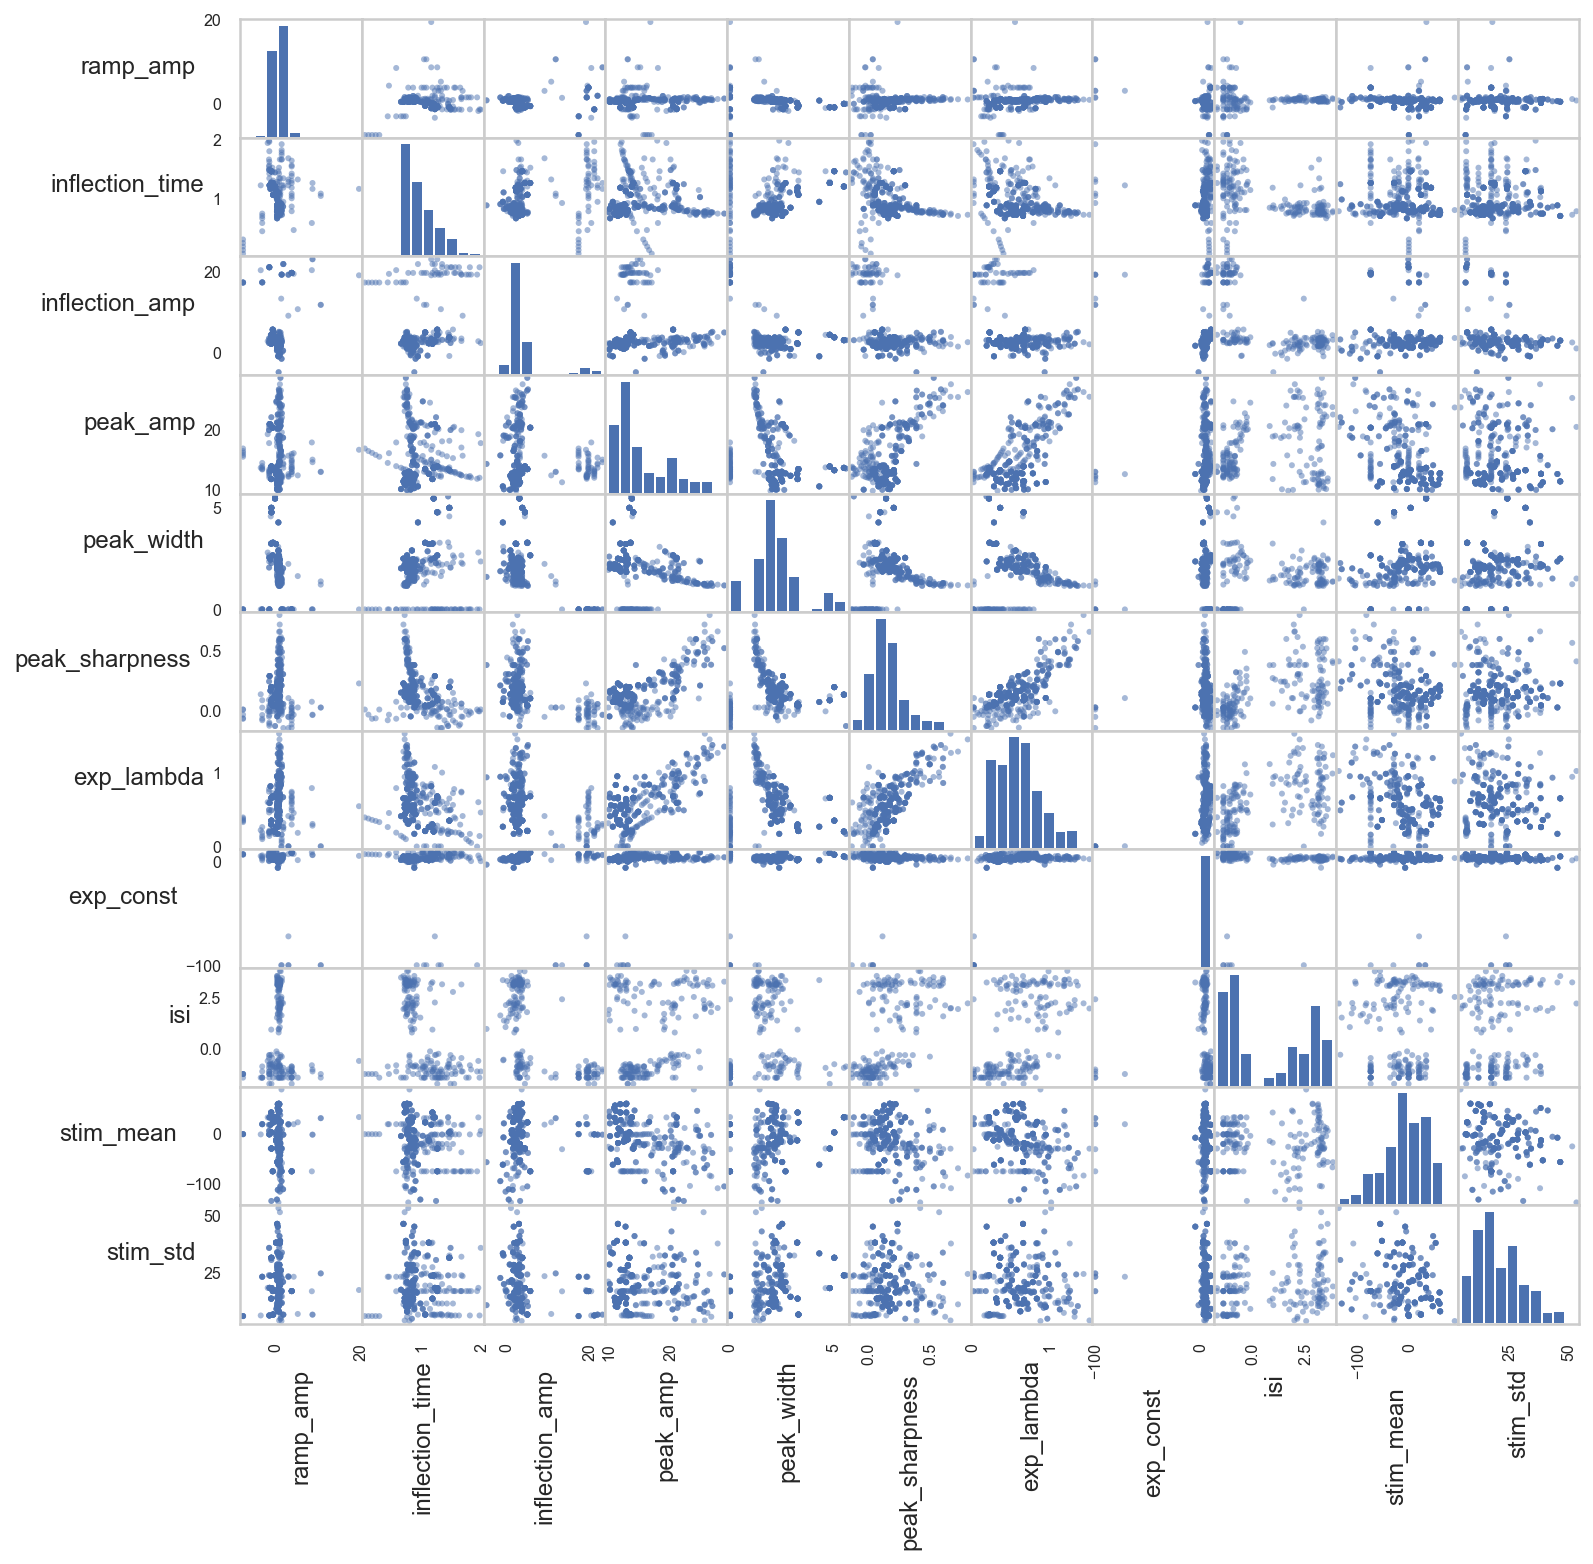

In [381]:
# Ensure inflection times are between 0 and 2 ms
df_drop_gamma_m2 = spk_gamma_features_m2.loc[spk_gamma_features_m2['inflection_time'] > 0.]
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['r_squared_exp']  >= .5]
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_gamma_m2[['isi']] = np.log10(df_drop_gamma_m2[['isi']])

# drop no-longer-used QC features
df_drop_gamma_m2 = df_drop_gamma_m2.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_gamma_m2 = df_drop_gamma_m2.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_gamma_m2, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

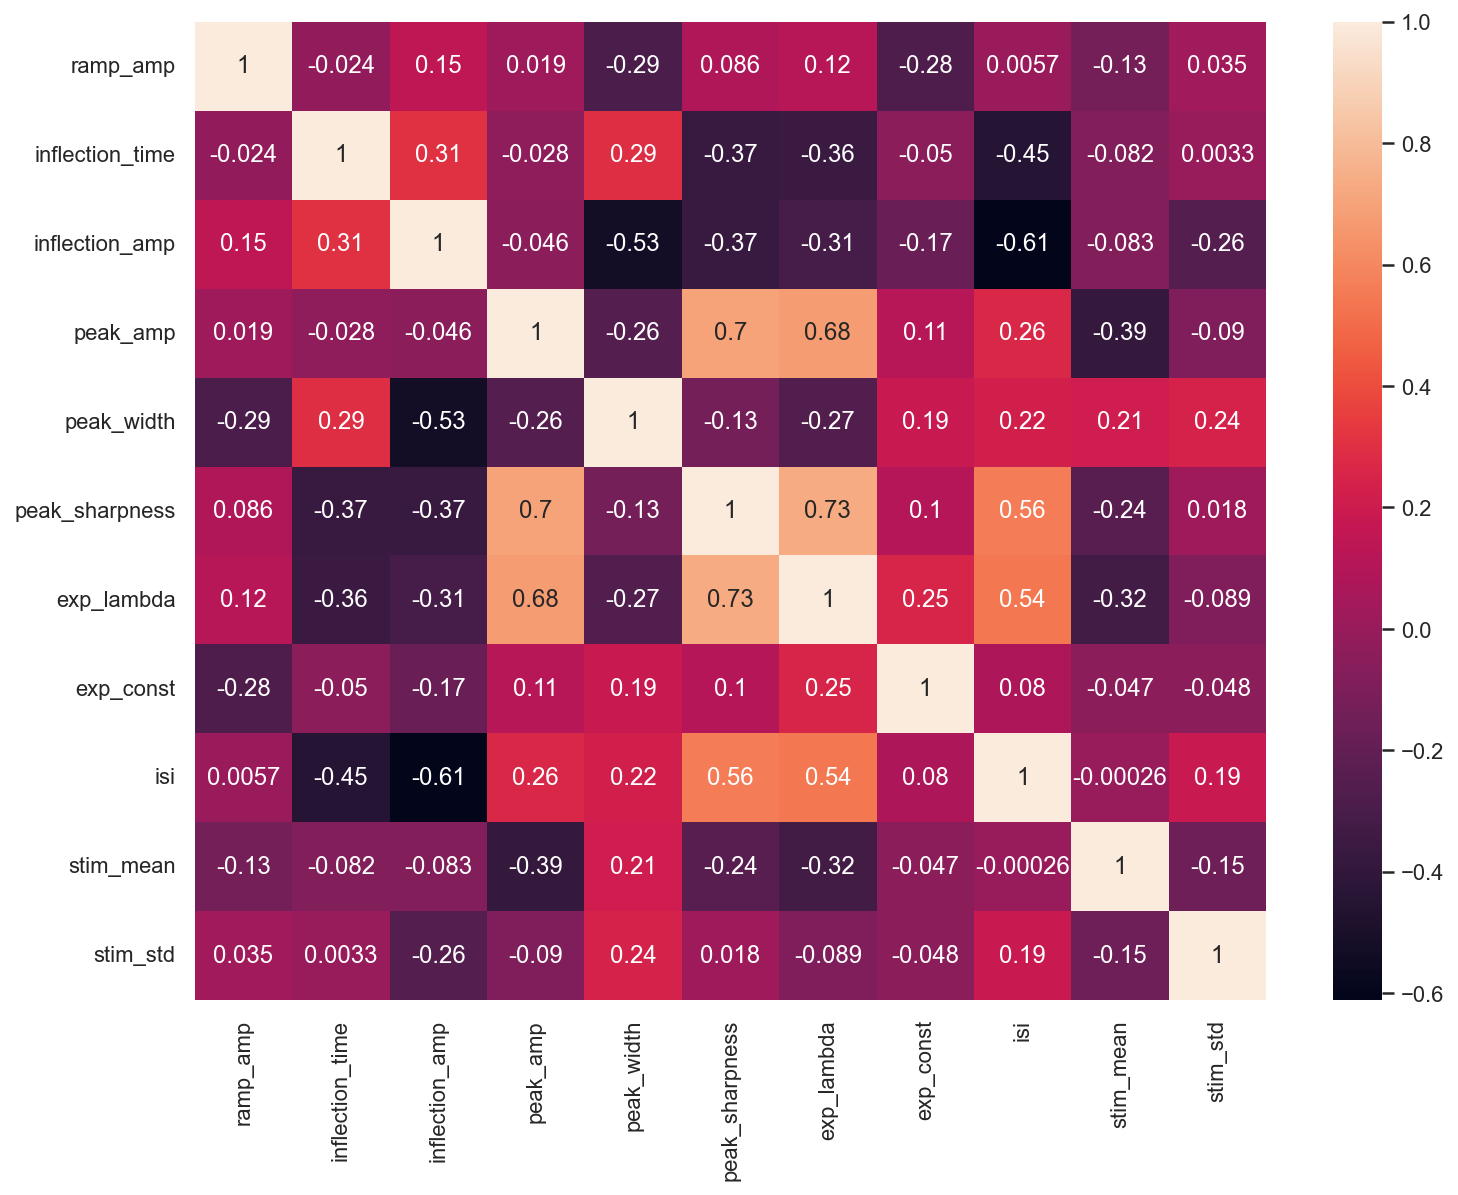

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,stim_mean,stim_std
ramp_amp,1.0***,-0.02,0.15***,0.02,-0.29***,0.09*,0.12**,-0.28***,0.01,-0.13**,0.04
inflection_time,-0.02,1.0***,0.31***,-0.03,0.29***,-0.37***,-0.36***,-0.05,-0.45***,-0.08,0.0
inflection_amp,0.15***,0.31***,1.0***,-0.05,-0.53***,-0.37***,-0.31***,-0.17***,-0.61***,-0.08,-0.26***
peak_amp,0.02,-0.03,-0.05,1.0***,-0.26***,0.7***,0.68***,0.11**,0.26***,-0.39***,-0.09*
peak_width,-0.29***,0.29***,-0.53***,-0.26***,1.0***,-0.13**,-0.27***,0.19***,0.22**,0.21***,0.24***
peak_sharpness,0.09*,-0.37***,-0.37***,0.7***,-0.13**,1.0***,0.73***,0.1*,0.56***,-0.24***,0.02
exp_lambda,0.12**,-0.36***,-0.31***,0.68***,-0.27***,0.73***,1.0***,0.25***,0.54***,-0.32***,-0.09*
exp_const,-0.28***,-0.05,-0.17***,0.11**,0.19***,0.1*,0.25***,1.0***,0.08,-0.05,-0.05
isi,0.01,-0.45***,-0.61***,0.26***,0.22**,0.56***,0.54***,0.08,1.0***,-0.0,0.19**
stim_mean,-0.13**,-0.08,-0.08,-0.39***,0.21***,-0.24***,-0.32***,-0.05,-0.0,1.0***,-0.15***


In [383]:
spikes_corr_gamma_m2 = df_drop_gamma_m2.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m2, xticklabels=spikes_corr_gamma_m2.columns, 
            yticklabels=spikes_corr_gamma_m2.columns, annot=True)
plt.show()

rho = df_drop_gamma_m2.corr()
pval = df_drop_gamma_m2.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### No gamma features

In [384]:
spk_no_gamma_features_m2

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,stim_mean,stim_std
211,1.112223,0.78,3.115583,27.212995,1.22,0.578949,1.519841,4.960342,85.179315,0.977741,0.994696,-91.260856,26.452428
212,1.380195,0.72,4.004042,28.106732,1.14,0.748175,1.347831,3.778150,74.424452,0.980072,0.998919,-65.251279,15.264984
213,0.927896,0.74,3.951865,26.744980,1.10,0.626017,1.478353,2.800181,594.376106,0.968425,0.997787,-27.309324,33.211403
214,1.609373,0.74,1.311271,26.605183,1.20,0.669609,1.054384,1.179627,56.153179,0.971186,0.998303,24.588877,56.976522
215,1.227065,0.72,2.038599,25.625221,1.18,0.745347,1.593197,3.844770,1132.339156,0.972375,0.997373,0.537517,63.315314
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3314,-0.841460,-0.66,10.335404,11.076632,1.46,0.091529,0.005112,-99.999766,0.039981,0.944893,0.987875,41.587776,4.724578
3315,-0.841460,-0.62,10.335404,10.991958,1.54,0.045755,0.005087,-100.000000,0.039981,0.944893,0.988546,41.587776,4.724578
3316,-0.841460,-0.58,10.335404,10.907311,1.56,-0.045796,0.005076,-100.000000,0.099952,0.944893,0.988713,41.587776,4.724578
3317,-0.841460,-0.48,10.335404,10.894106,1.56,0.091401,0.005072,-100.000000,0.000000,0.944893,0.988764,41.587776,4.724578


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/internals/blocks.py:402: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


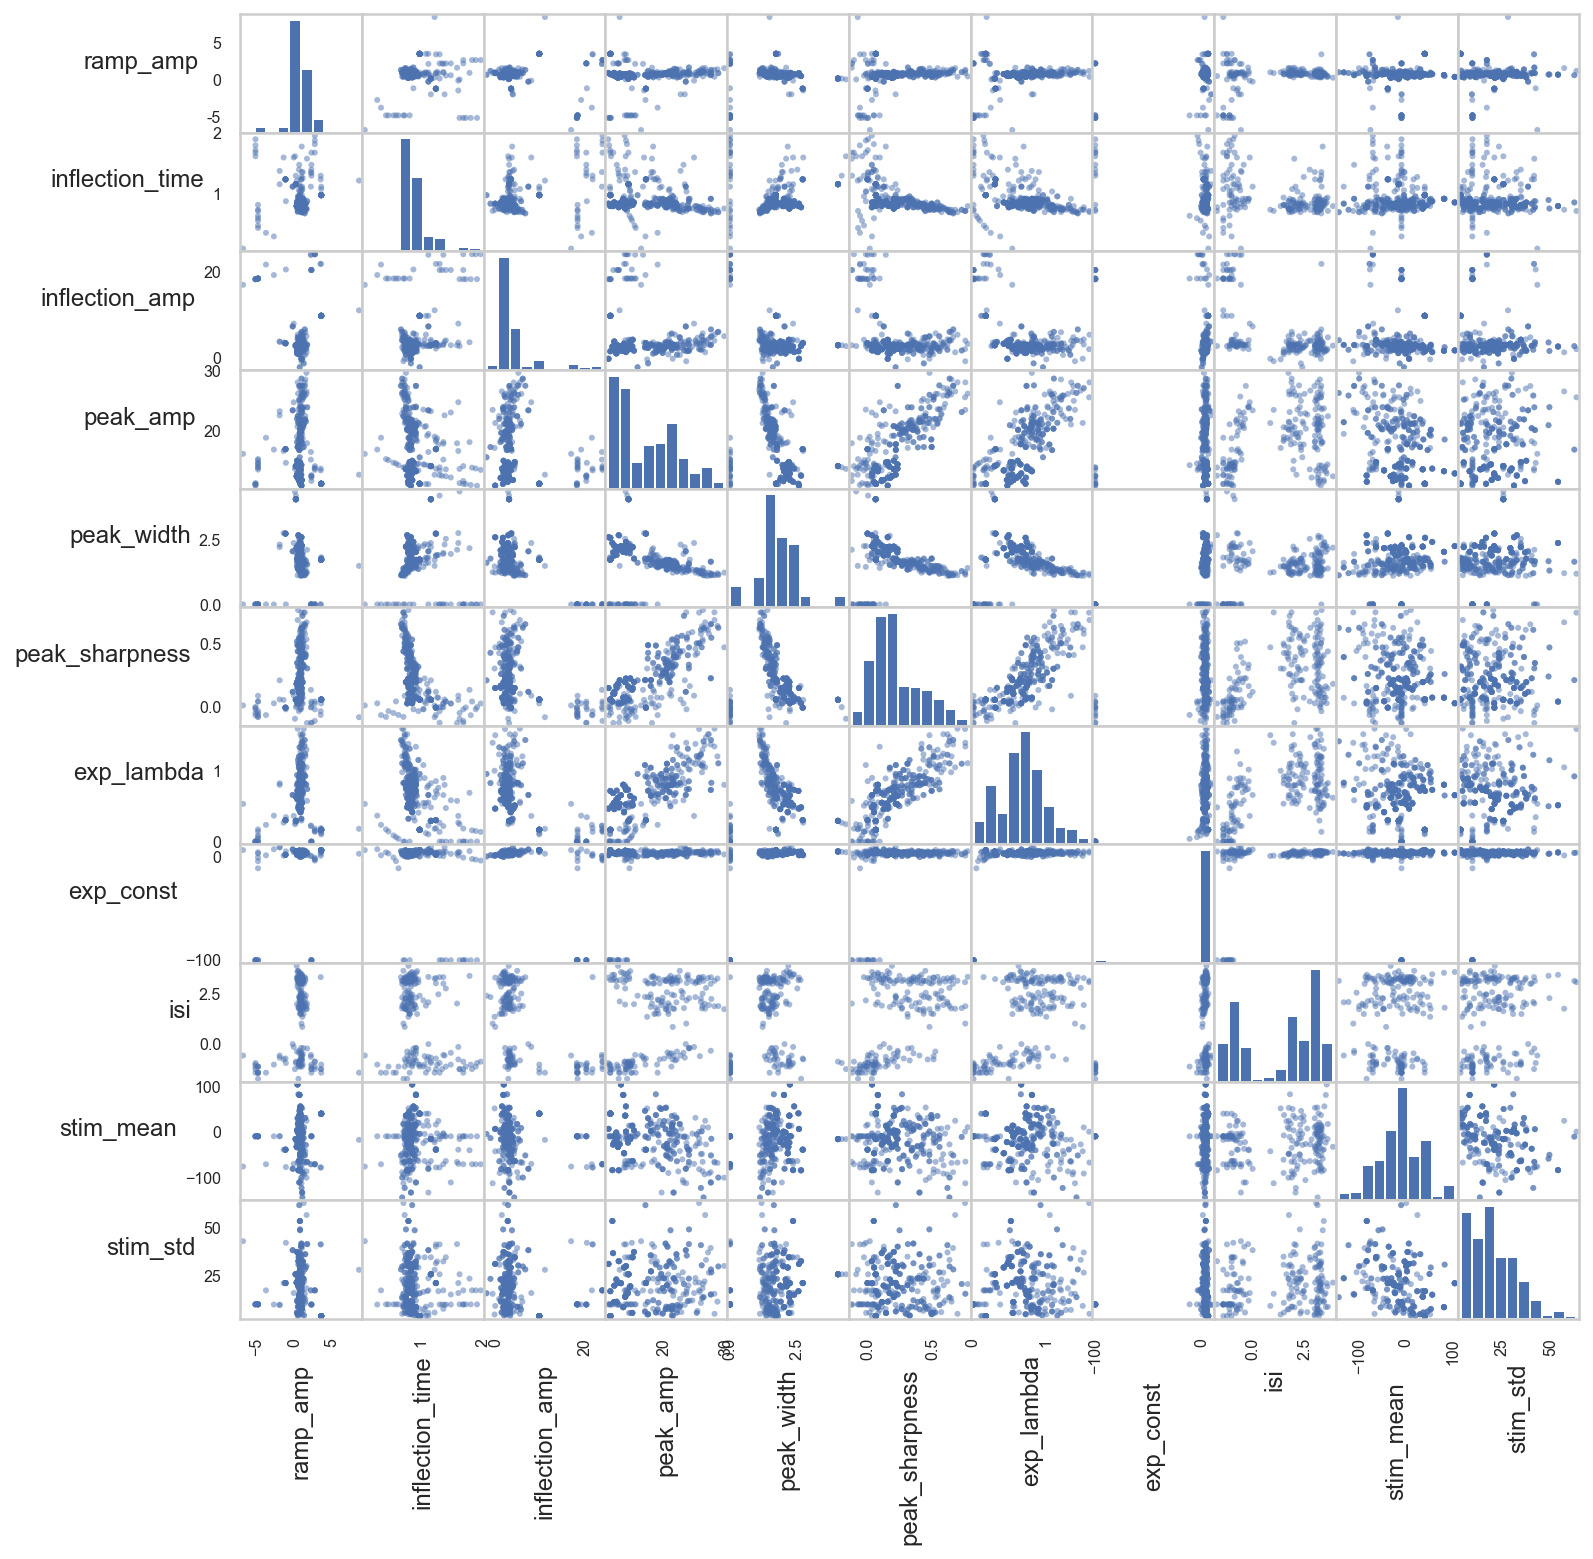

In [385]:
# Ensure inflection times are between 0 and 2 ms
df_drop_no_gamma_m2 = spk_no_gamma_features_m2.loc[spk_no_gamma_features_m2['inflection_time'] > 0.]
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['r_squared_exp']  >= .5]
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_no_gamma_m2[['isi']] = np.log10(df_drop_no_gamma_m2[['isi']])

# drop no-longer-used QC features
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m2, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

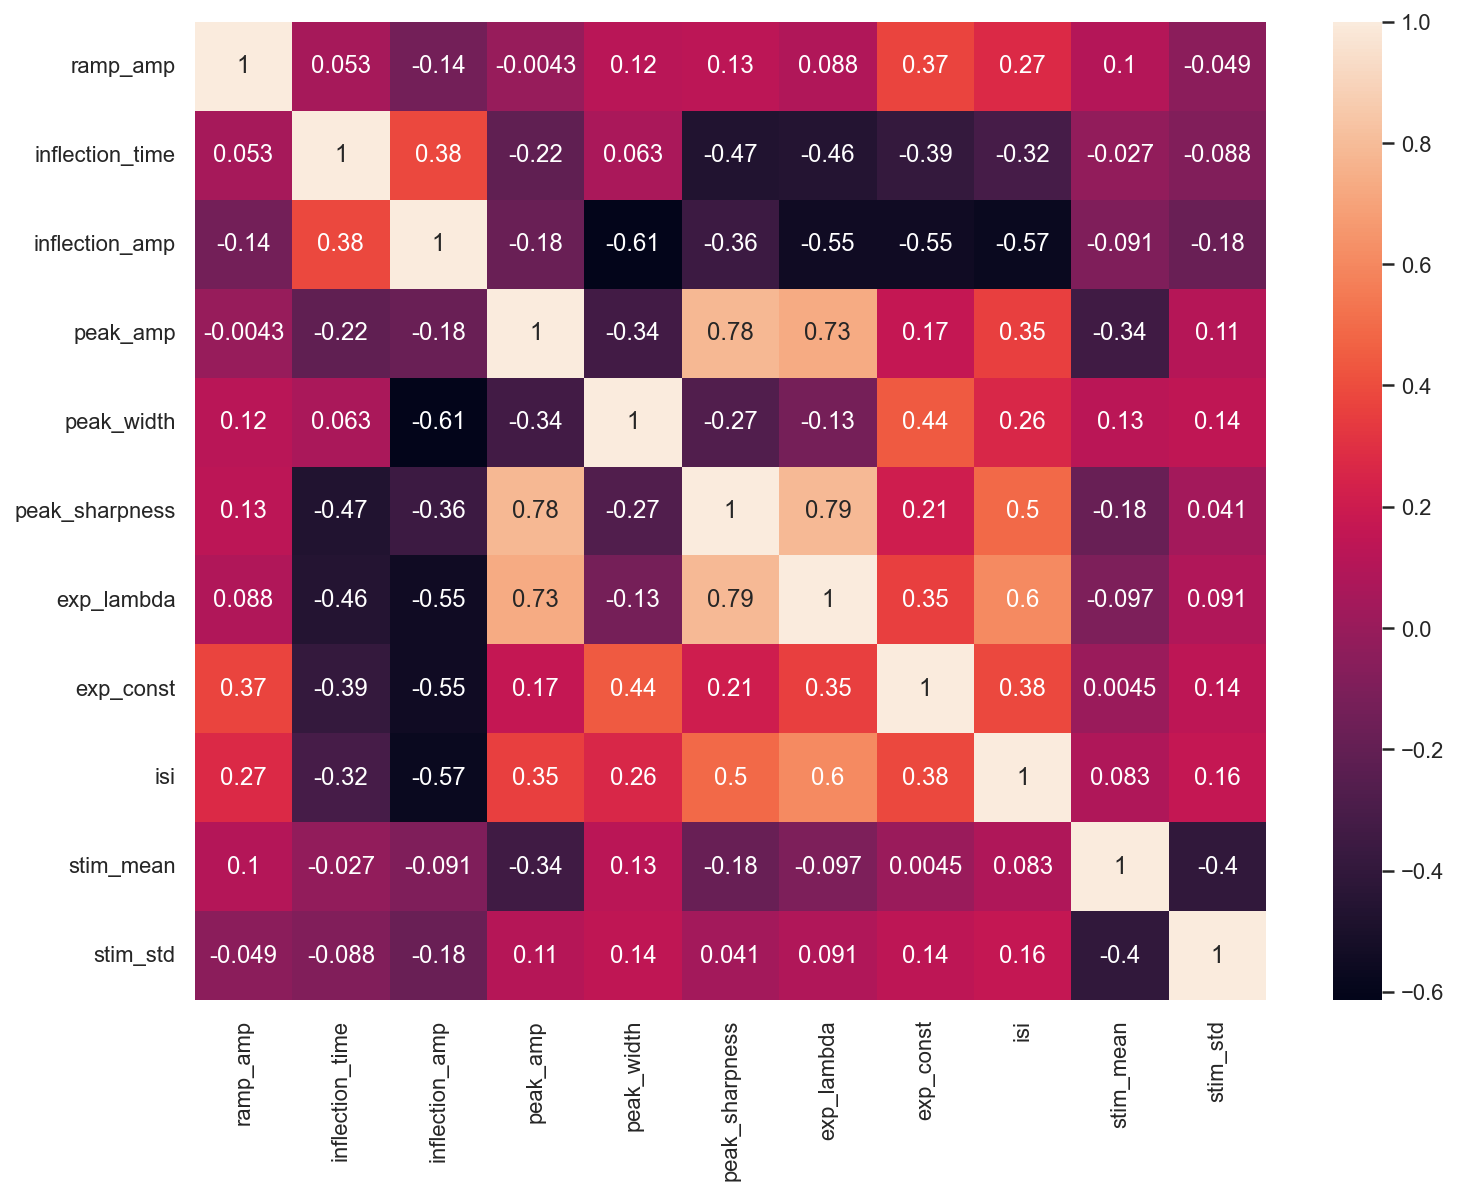

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,stim_mean,stim_std
ramp_amp,1.0***,0.05,-0.14**,-0.0,0.12**,0.13**,0.09,0.37***,0.27***,0.1*,-0.05
inflection_time,0.05,1.0***,0.38***,-0.22***,0.06,-0.47***,-0.46***,-0.39***,-0.32***,-0.03,-0.09
inflection_amp,-0.14**,0.38***,1.0***,-0.18***,-0.61***,-0.36***,-0.55***,-0.55***,-0.57***,-0.09,-0.18***
peak_amp,-0.0,-0.22***,-0.18***,1.0***,-0.34***,0.78***,0.73***,0.17***,0.35***,-0.34***,0.11*
peak_width,0.12**,0.06,-0.61***,-0.34***,1.0***,-0.27***,-0.13**,0.44***,0.26***,0.13**,0.14**
peak_sharpness,0.13**,-0.47***,-0.36***,0.78***,-0.27***,1.0***,0.79***,0.21***,0.5***,-0.18***,0.04
exp_lambda,0.09,-0.46***,-0.55***,0.73***,-0.13**,0.79***,1.0***,0.35***,0.6***,-0.1*,0.09
exp_const,0.37***,-0.39***,-0.55***,0.17***,0.44***,0.21***,0.35***,1.0***,0.38***,0.0,0.14**
isi,0.27***,-0.32***,-0.57***,0.35***,0.26***,0.5***,0.6***,0.38***,1.0***,0.08,0.16*
stim_mean,0.1*,-0.03,-0.09,-0.34***,0.13**,-0.18***,-0.1*,0.0,0.08,1.0***,-0.4***


In [386]:
spikes_corr_no_gamma_m2 = df_drop_no_gamma_m2.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m2, xticklabels=spikes_corr_no_gamma_m2.columns, 
            yticklabels=spikes_corr_no_gamma_m2.columns, annot=True)
plt.show()

rho = df_drop_no_gamma_m2.corr()
pval = df_drop_no_gamma_m2.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### Compare features between gamma and no gamma spike groups (initial descriptive)

In [387]:
columns = df_drop_gamma_m2.columns.values.tolist()

In [388]:
df_drop_gamma_m2.mean()

ramp_amp            0.478168
inflection_time     0.964044
inflection_amp      4.264948
peak_amp           15.223575
peak_width          2.253787
peak_sharpness      0.164437
exp_lambda          0.582864
exp_const           2.784695
isi                 0.755511
stim_mean          -9.644779
stim_std           20.799643
dtype: float64

In [389]:
df_drop_no_gamma_m2.mean()

ramp_amp            0.711747
inflection_time     0.906096
inflection_amp      4.271240
peak_amp           17.121846
peak_width          1.784474
peak_sharpness      0.220307
exp_lambda          0.678969
exp_const           0.645274
isi                 1.372849
stim_mean         -13.411924
stim_std           20.344674
dtype: float64

In [390]:
df_drop_gamma_m2.std()

ramp_amp            1.765343
inflection_time     0.271456
inflection_amp      5.149085
peak_amp            4.350110
peak_width          1.231983
peak_sharpness      0.145803
exp_lambda          0.290240
exp_const          11.598529
isi                 1.921194
stim_mean          42.007260
stim_std           10.047149
dtype: float64

In [391]:
df_drop_no_gamma_m2.std()

ramp_amp            1.415795
inflection_time     0.219231
inflection_amp      4.735286
peak_amp            4.844061
peak_width          0.737345
peak_sharpness      0.188219
exp_lambda          0.327130
exp_const          17.348074
isi                 1.814289
stim_mean          45.756678
stim_std           12.166502
dtype: float64

#### Visualize differences in mean and std between gamma and non gamma groups

##### Stats for compared features

In [392]:
# Combine group dataframes into one df with a tag column
groups = {'gamma': df_drop_gamma_m2, 'no_gamma': df_drop_no_gamma_m2}
df_concate_ggroups_m2 = pd.concat(groups, names=['LFP_class'])
df_concate_ggroups_m2 = df_concate_ggroups_m2.reset_index(level=0)



In [393]:
df_concate_ggroups_m2

,LFP_class,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,stim_mean,stim_std
0,gamma,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,NaN,-50.463271,8.117908
1,gamma,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,-50.463271,8.117908
216,gamma,0.996990,0.74,3.868878,27.462563,1.22,0.658564,1.258951,4.281266,1.989776,-109.877508,37.792683
217,gamma,0.950415,0.70,1.531837,25.351521,1.20,0.715407,1.276490,2.345120,1.939711,-70.012179,11.317864
218,gamma,1.126602,0.74,4.988691,28.515338,1.18,0.520198,1.343561,4.523581,NaN,-106.183009,24.348341
...,...,...,...,...,...,...,...,...,...,...,...,...
3304,no_gamma,3.553169,0.98,9.775849,11.243554,1.72,0.060912,0.175499,6.126011,NaN,40.214239,3.442924
3305,no_gamma,3.553169,0.98,9.775849,11.243554,1.72,0.060912,0.175499,6.126011,NaN,40.214239,3.442924
3306,no_gamma,3.553169,0.98,9.775849,11.243554,1.72,0.060912,0.175499,6.126011,-1.000207,40.214239,3.442924
3307,no_gamma,3.553169,1.08,9.775849,11.199035,1.80,0.030478,0.128492,4.907668,-1.398147,40.214239,3.442924


##### Run t-tests for variables

In [394]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m2[c][df_concate_ggroups_m2['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m2[c][df_concate_ggroups_m2['LFP_class'] == 'no_gamma'], nan_policy='omit'))

ramp_amp t-test
Ttest_indResult(statistic=-2.2774014666027984, pvalue=0.022973115537279067)
inflection_time t-test
Ttest_indResult(statistic=3.6652558093417626, pvalue=0.00026010813185256494)
inflection_amp t-test
Ttest_indResult(statistic=-0.01995898970085933, pvalue=0.9840800770351821)
peak_amp t-test
Ttest_indResult(statistic=-6.525185901842314, pvalue=1.0783286240142927e-10)
peak_width t-test
Ttest_indResult(statistic=7.133586016010462, pvalue=1.8770993071873983e-12)
peak_sharpness t-test
Ttest_indResult(statistic=-5.285402349230033, pvalue=1.5404778294447465e-07)
exp_lambda t-test
Ttest_indResult(statistic=-4.920731599054046, pvalue=1.0081137230925693e-06)
exp_const t-test
Ttest_indResult(statistic=2.3230146962225056, pvalue=0.020378623546307015)
isi t-test
Ttest_indResult(statistic=-3.283819819559054, pvalue=0.0011158792483995212)
stim_mean t-test
Ttest_indResult(statistic=1.3559737816318878, pvalue=0.17541423150313198)
stim_std t-test
Ttest_indResult(statistic=0.6476753808111564

##### Compare cross correlation matrices

In [395]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m2)))

SignificanceResult(statistic=0.7935064935064937, pvalue=5.032921369761001e-13)


##### Data is not independent so using this pvalues is misleading. To test for significance, 

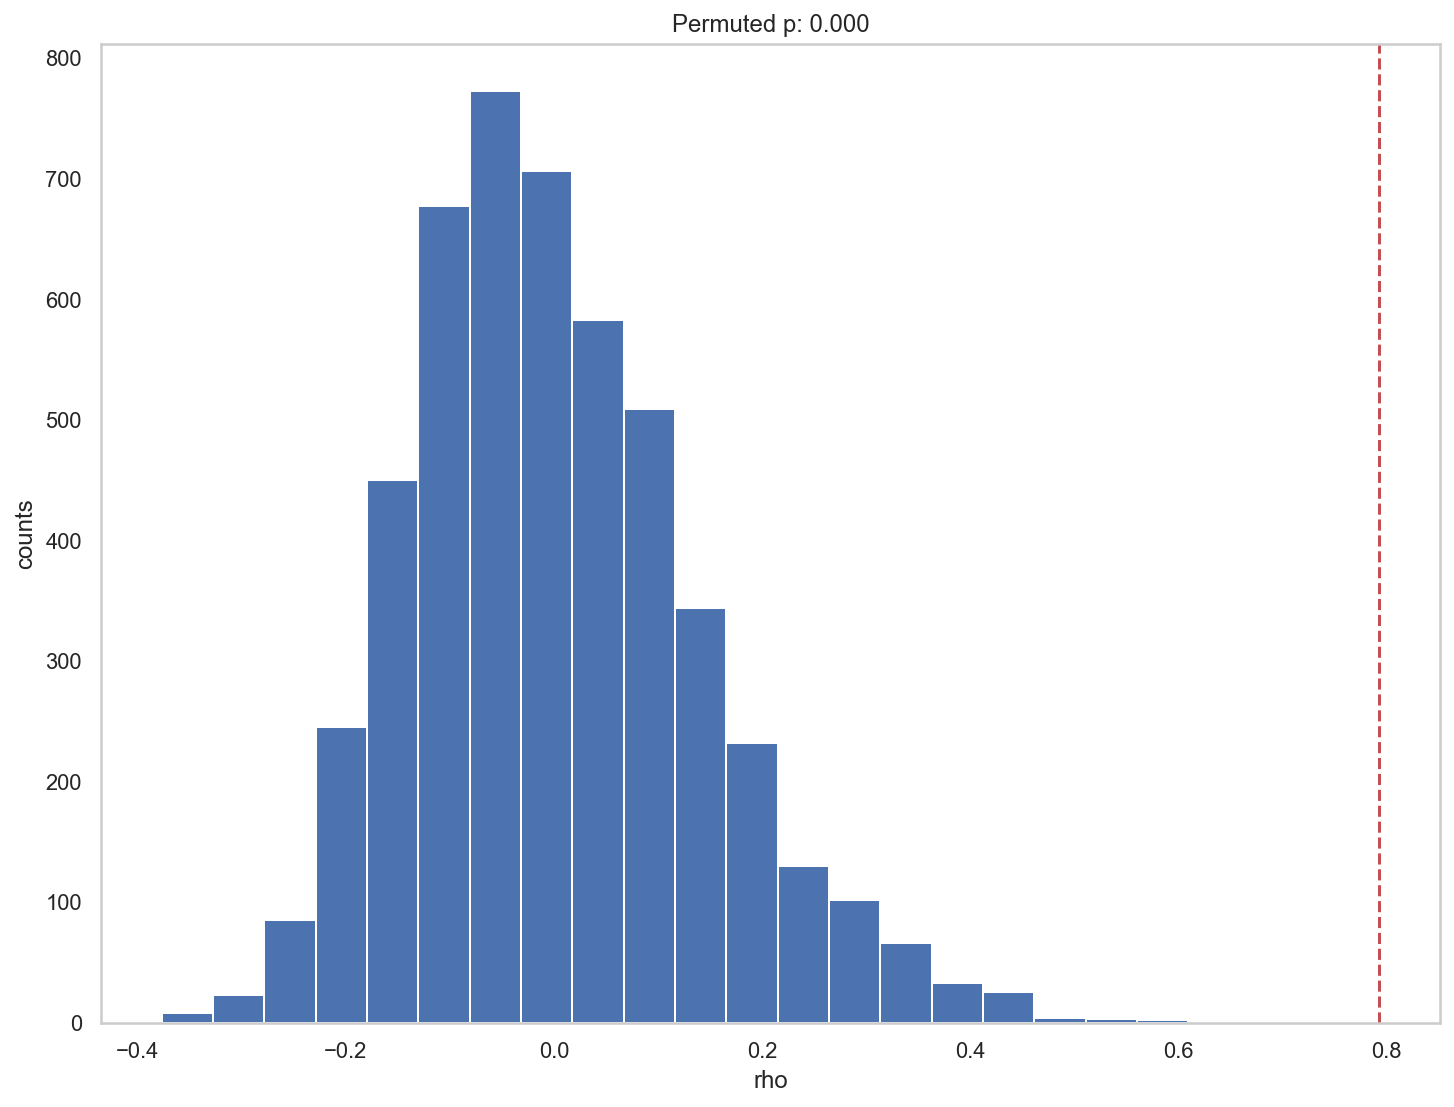

In [396]:
"""Nonparametric permutation testing Monte Carlo"""
np.random.seed(0)
rhos = []
n_iter = 5000
true_rho, _ = stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m2))
# matrix permutation, shuffle the groups
m_ids = list(spikes_corr_gamma_m2.columns)
m2_v = upper(spikes_corr_no_gamma_m2)
for iter in range(n_iter):
  np.random.shuffle(m_ids) # shuffle list 
  r, _ = stats.spearmanr(upper(spikes_corr_gamma_m2.loc[m_ids, m_ids]), m2_v)  
  rhos.append(r)
perm_p = ((np.sum(np.abs(true_rho) <= np.abs(rhos)))+1)/(n_iter+1) # two-tailed test


f,ax = plt.subplots()
plt.hist(rhos,bins=20)
ax.axvline(true_rho,  color = 'r', linestyle='--')
ax.set(title=f"Permuted p: {perm_p:.3f}", ylabel="counts", xlabel="rho")
plt.show()

##### Cross-correlation matrices are significantly similar :()

### Look into burst/number of spikes info